# Milestone 2: Multimodal PD Progression Analysis
## PPMI Dataset — Tabular Clinical Modality (Phase 1)

**Team:** Ibrahim Khaled Almuteb & Aishwarya Naik  
**Course:** CSE 689 — AI Project | Texas A&M University | Spring 2025  
**Note:** MRI imaging pipeline is pending (next phase). This notebook covers full tabular analysis.

---

### What this notebook produces
| Section | Output |
|---|---|
| 0. Setup | Drive mount, installs, imports |
| 1. Data Loading | Verify all preprocessed files |
| 2. Cohort Overview | Patient counts, visit heatmap |
| 3. Score Distributions | Baseline scores by group |
| 4. Progression Slopes | Trajectory plots, slope statistics |
| 5. Feature Correlation | Heatmap + baseline vs slope |
| 6. Supervised Regression | Ridge / RF / GBM / XGBoost with CV |
| 7. Clustering | Hopkins, Elbow, K-Means, Agglomerative |
| 8. Graph + Node2Vec | Patient graph topology + embeddings |
| 9. Summary Table | All results in one place |


## 0. Setup

**Run this cell first, then restart runtime, then run all remaining cells.**

In [1]:
# import subprocess, sys

# # Pin numpy to avoid binary incompatibility with umap/node2vec
# subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
#     'umap-learn==0.5.6',
#     'node2vec==0.4.6',
#     'numpy==1.26.4',
#     'xgboost',
# ])
# print("✓ Packages installed — RESTART RUNTIME now, then run all cells from top")


## 0.1 Mount Drive & Verify Paths

In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')

OUTPUT_PATH = '/content/drive/My Drive/Colab Notebooks/CSE676/project/ML_READY/'
FIG_PATH    = OUTPUT_PATH + 'milestone2_figs/'
os.makedirs(FIG_PATH, exist_ok=True)

# Verify all required files exist
required = [
    'tabular/merged_clinical.csv',
    'tabular/labels.csv',
    'tabular/feature_matrix.csv',
    'eda/progression_slopes.csv',
]
print("File check:")
all_ok = True
for f in required:
    exists = os.path.exists(OUTPUT_PATH + f)
    sz = f"{os.path.getsize(OUTPUT_PATH+f)/1e6:.1f} MB" if exists else "MISSING"
    print(f"  {'✓' if exists else '✗'} {f}  ({sz})")
    if not exists: all_ok = False

print("\n✓ All files ready — proceed!" if all_ok else "\n✗ Some files missing — re-run preprocessing scripts first")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File check:
  ✓ tabular/merged_clinical.csv  (2.8 MB)
  ✓ tabular/labels.csv  (0.1 MB)
  ✓ tabular/feature_matrix.csv  (14.8 MB)
  ✓ eda/progression_slopes.csv  (0.2 MB)

✓ All files ready — proceed!


## 0.2 Imports & Plot Config

In [3]:
import warnings, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, kruskal, mannwhitneyu

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             mean_squared_error, r2_score)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score, KFold, cross_validate
from sklearn.inspection import permutation_importance
import networkx as nx
import xgboost as xgb

from umap import UMAP
from node2vec import Node2Vec

# ── Plot style ────────────────────────────────────────────────────────────
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans', 'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_theme(style='whitegrid', font_scale=1.05)

PALETTE = {
    'PD':'#E05C5C', 'HC':'#5C9BE0', 'SWEDD':'#F0A500',
    'Prodromal':'#7CBF6E', 'Other':'#AAAAAA'
}
GROUPS = ['PD','SWEDD','HC','Prodromal']
print("✓ Imports complete")


✓ Imports complete


## 1. Load Data

In [4]:
# ── Load preprocessed files ───────────────────────────────────────────────
merged   = pd.read_csv(OUTPUT_PATH + 'tabular/merged_clinical.csv', low_memory=False)
labels   = pd.read_csv(OUTPUT_PATH + 'tabular/labels.csv',          low_memory=False)
feat_mat = pd.read_csv(OUTPUT_PATH + 'tabular/feature_matrix.csv',  low_memory=False)
slopes   = pd.read_csv(OUTPUT_PATH + 'eda/progression_slopes.csv',  low_memory=False)

# ── Merge labels ──────────────────────────────────────────────────────────
merged = merged.merge(labels[['PATNO','LABEL']], on='PATNO', how='left')
merged['LABEL'] = merged['LABEL'].fillna('Unlabeled')

# ── Visit → months ────────────────────────────────────────────────────────
VISIT_MONTHS = {
    'SC':-6,'BL':0,'V01':3,'V02':6,'V03':9,'V04':12,'V05':18,
    'V06':24,'V07':30,'V08':36,'V09':42,'V10':48,'V11':54,
    'V12':60,'V13':66,'V14':72,'V15':78,'V16':84
}
merged['VISIT_MONTH'] = merged['EVENT_ID'].map(VISIT_MONTHS)

# ── Score columns ─────────────────────────────────────────────────────────
SCORE_COLS = [c for c in merged.columns
              if c not in ['PATNO','EVENT_ID','LABEL','VISIT_MONTH']
              and pd.api.types.is_numeric_dtype(merged[c])]

# ── Reliable slopes (≥3 visits, ≥12 month span) ───────────────────────────
reliable = slopes[(slopes['N_VISITS'] >= 3) & (slopes['MONTHS_SPAN'] >= 12)].copy()
if 'LABEL' not in reliable.columns:
    reliable = reliable.merge(labels[['PATNO','LABEL']], on='PATNO', how='left')

print(f"merged_clinical : {merged.shape[0]:,} rows × {merged.shape[1]} cols")
print(f"feature_matrix  : {feat_mat.shape[0]:,} rows × {feat_mat.shape[1]} cols")
print(f"labels          : {len(labels):,} patients")
print(f"reliable slopes : {len(reliable):,} patients  (median visits={reliable['N_VISITS'].median():.0f})")
print(f"Score columns   : {SCORE_COLS}")
print(f"\nLabel distribution:")
print(labels['LABEL'].value_counts().to_string())


merged_clinical : 42,157 rows × 23 cols
feature_matrix  : 42,157 rows × 19 cols
labels          : 4,899 patients
reliable slopes : 2,961 patients  (median visits=6)
Score columns   : ['UPDRS1_TOTAL', 'UPDRS1PQ_TOTAL', 'UPDRS2_TOTAL', 'UPDRS3_TOTAL', 'UPDRS4_TOTAL', 'SCHWAB_SCORE', 'MOCA_TOTAL', 'GDS_TOTAL', 'ESS_TOTAL', 'RBD_TOTAL', 'UPSIT_TOTAL', 'STAI_TOTAL', 'SCOPA_TOTAL', 'WGTKG', 'HTCM', 'TEMPC', 'SYSSUP', 'DIASUP', 'HRSUP']

Label distribution:
LABEL
PD           1790
SWEDD        1659
HC           1149
Other         200
Prodromal     101


## 2. Cohort Overview

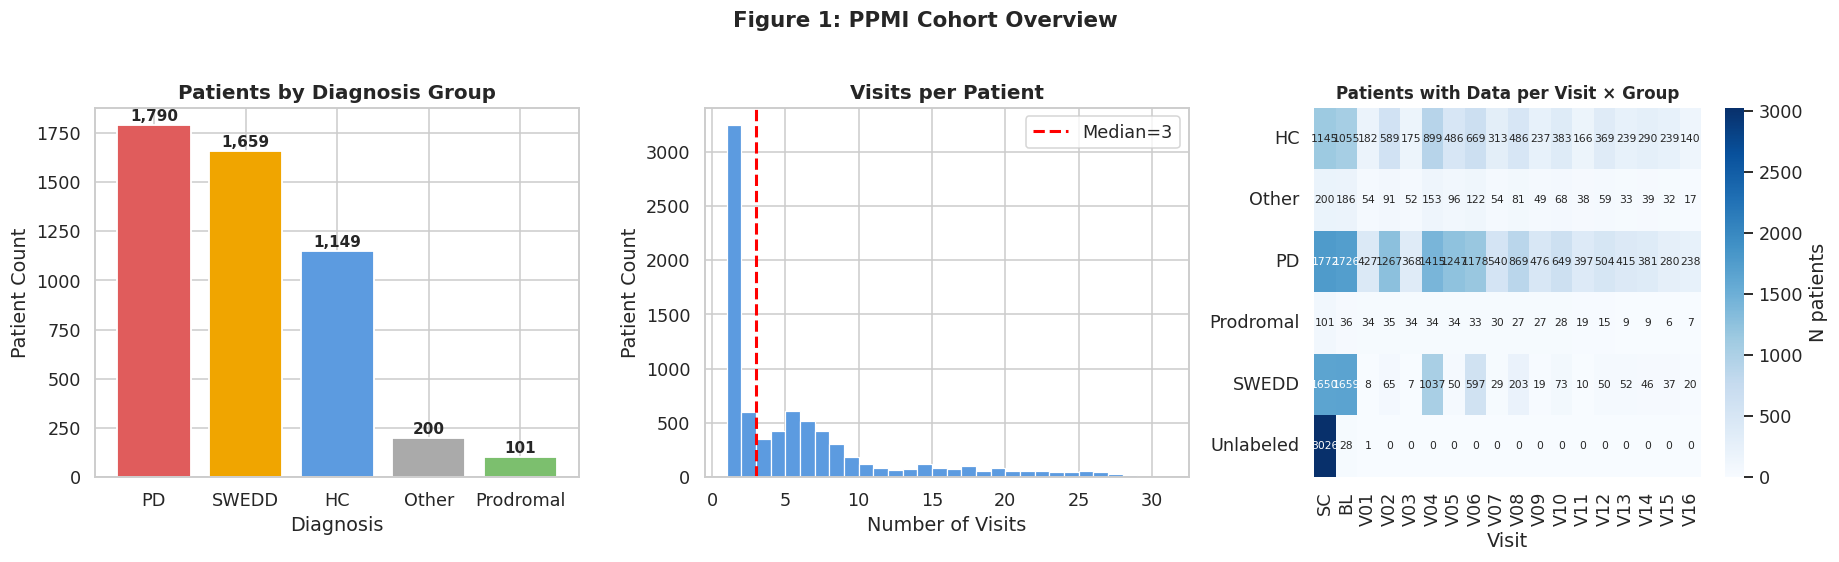

✓ Saved fig1_cohort_overview.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Panel A: Patient counts by group ─────────────────────────────────────
label_counts = labels['LABEL'].value_counts()
colors = [PALETTE.get(l, '#AAAAAA') for l in label_counts.index]
bars = axes[0].bar(label_counts.index, label_counts.values,
                   color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Patients by Diagnosis Group', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Diagnosis'); axes[0].set_ylabel('Patient Count')

# ── Panel B: Visits per patient ───────────────────────────────────────────
vpp = merged.groupby('PATNO')['EVENT_ID'].nunique()
axes[1].hist(vpp, bins=range(1, int(vpp.max())+2), color='#5C9BE0',
             edgecolor='white', linewidth=0.8)
axes[1].axvline(vpp.median(), color='red', lw=2, linestyle='--',
                label=f'Median={vpp.median():.0f}')
axes[1].set_title('Visits per Patient', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Number of Visits'); axes[1].set_ylabel('Patient Count')
axes[1].legend()

# ── Panel C: Visit coverage heatmap ──────────────────────────────────────
EVENT_ORDER = ['SC','BL','V01','V02','V03','V04','V05','V06',
               'V07','V08','V09','V10','V11','V12','V13','V14','V15','V16']
vc = (merged.groupby(['LABEL','EVENT_ID'])['PATNO']
           .nunique().reset_index()
           .pivot(index='LABEL', columns='EVENT_ID', values='PATNO')
           .fillna(0))
valid_events = [e for e in EVENT_ORDER if e in vc.columns]
vc = vc[valid_events]
sns.heatmap(vc, ax=axes[2], cmap='Blues', annot=True, fmt='.0f',
            annot_kws={'size': 7}, cbar_kws={'label': 'N patients'})
axes[2].set_title('Patients with Data per Visit × Group', fontweight='bold', fontsize=11)
axes[2].set_xlabel('Visit'); axes[2].set_ylabel('')

plt.suptitle('Figure 1: PPMI Cohort Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH + 'fig1_cohort_overview.png', bbox_inches='tight')
plt.show()
print("✓ Saved fig1_cohort_overview.png")


## 3. Baseline Score Distributions by Group

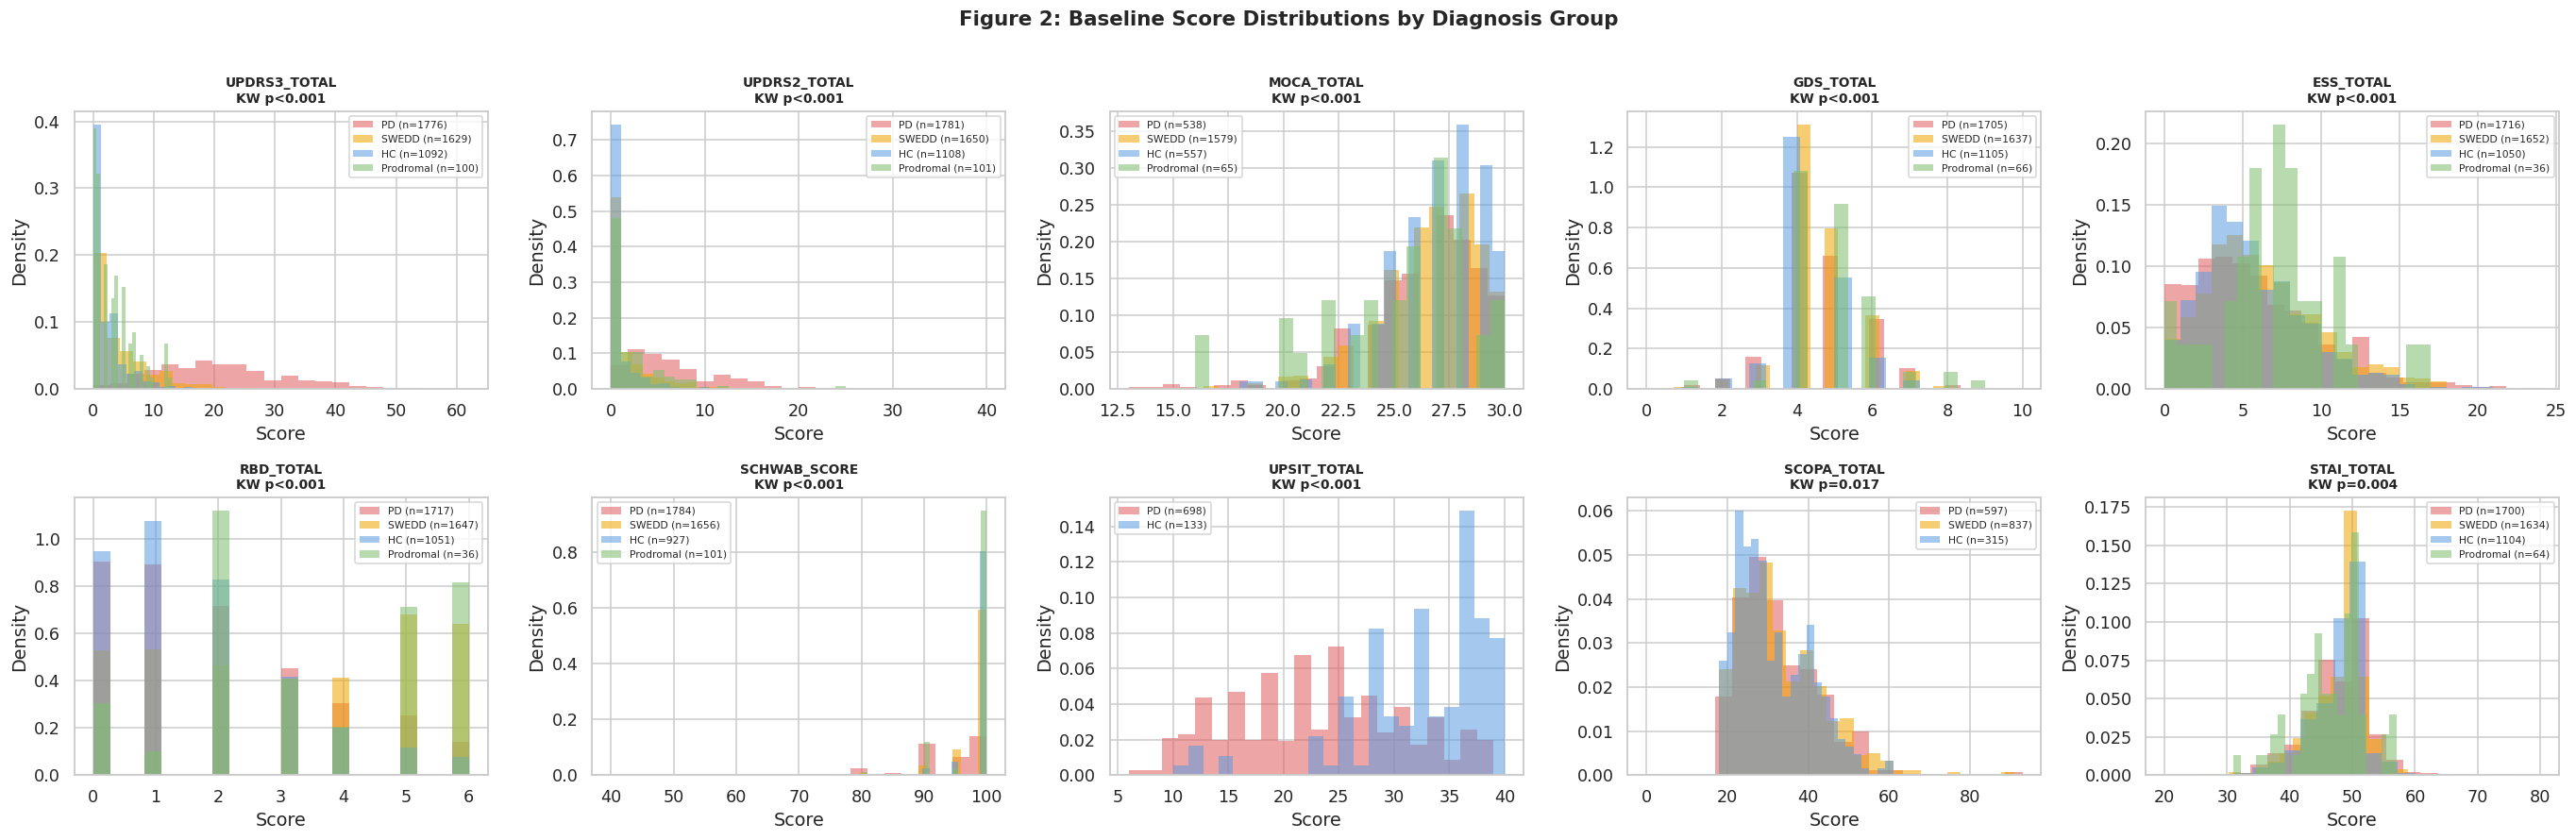


Kruskal-Wallis results (most significant first):
     feature      H       p_value  sig
UPDRS3_TOTAL 2767.2  0.000000e+00 True
UPDRS2_TOTAL 1841.2  0.000000e+00 True
SCHWAB_SCORE 1133.4 2.067585e-245 True
   RBD_TOTAL  459.0  3.741661e-99 True
 UPSIT_TOTAL  154.6  1.669982e-35 True
   GDS_TOTAL   60.5  4.563490e-13 True
   ESS_TOTAL   32.0  5.327773e-07 True
  MOCA_TOTAL   19.9  1.754061e-04 True
  STAI_TOTAL   13.4  3.819785e-03 True
 SCOPA_TOTAL    8.1  1.739545e-02 True


In [6]:
bl = merged[merged['EVENT_ID'].isin(['BL','SC'])].drop_duplicates('PATNO')
bl_labeled = bl[bl['LABEL'].isin(GROUPS)]

key_scores = [c for c in ['UPDRS3_TOTAL','UPDRS2_TOTAL','MOCA_TOTAL',
                            'GDS_TOTAL','ESS_TOTAL','RBD_TOTAL',
                            'SCHWAB_SCORE','UPSIT_TOTAL','SCOPA_TOTAL',
                            'STAI_TOTAL'] if c in merged.columns]

ncols = 5
nrows = (len(key_scores) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes_flat = np.array(axes).flatten()

stat_results = []
for ax, col in zip(axes_flat, key_scores):
    group_data = []
    for label in GROUPS:
        d = bl_labeled[bl_labeled['LABEL']==label][col].dropna()
        if len(d) > 5:
            ax.hist(d, bins=22, alpha=0.55, label=f'{label} (n={len(d)})',
                    color=PALETTE[label], density=True, edgecolor='none')
            group_data.append(d)
    if len(group_data) >= 2:
        h, p = kruskal(*group_data)
        p_str = 'p<0.001' if p < 0.001 else f'p={p:.3f}'
        stat_results.append({'feature':col,'H':round(h,1),'p_value':p,'sig':p<0.05})
    ax.set_title(f'{col}\nKW {p_str}' if len(group_data)>=2 else col,
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Score'); ax.set_ylabel('Density')
    ax.legend(fontsize=7)

for ax in axes_flat[len(key_scores):]:
    ax.set_visible(False)

plt.suptitle('Figure 2: Baseline Score Distributions by Diagnosis Group',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_PATH + 'fig2_score_distributions.png', bbox_inches='tight')
plt.show()

stat_df = pd.DataFrame(stat_results).sort_values('H', ascending=False)
print("\nKruskal-Wallis results (most significant first):")
print(stat_df.to_string(index=False))


## 4. UPDRS-III Longitudinal Trajectories & Progression Slopes

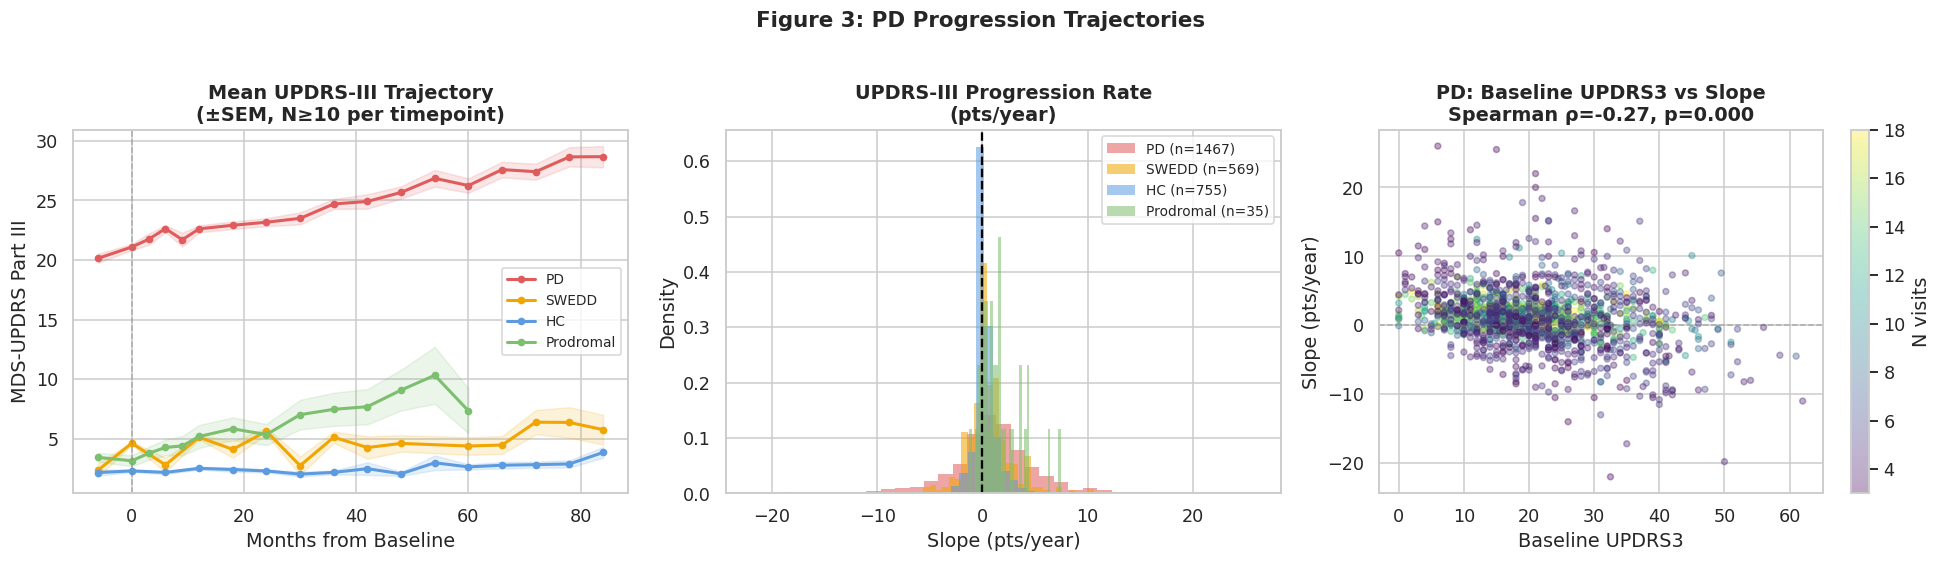


=== Progression Slope Summary (pts/year) ===
Group             N     Mean   Median      Std
----------------------------------------------
PD             1467     1.13     1.01     4.26
SWEDD           569     0.60     0.20     2.36
HC              755     0.22     0.06     1.35
Prodromal        35     1.62     1.16     1.94

PD fast progressors (>5 pts/yr) : 190 (13.0%)
PD slow/stable (<1 pt/yr)        : 726 (49.5%)
PD range                         : -22.0 to 26.0


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel A: Mean trajectory ± SEM ───────────────────────────────────────
traj = merged[merged['LABEL'].isin(GROUPS)].dropna(subset=['VISIT_MONTH','UPDRS3_TOTAL'])
traj_summary = (traj.groupby(['LABEL','VISIT_MONTH'])['UPDRS3_TOTAL']
                    .agg(['mean','sem','count']).reset_index())
for label in GROUPS:
    d = traj_summary[(traj_summary['LABEL']==label) & (traj_summary['count']>=10)]
    if len(d):
        axes[0].plot(d['VISIT_MONTH'], d['mean'], marker='o', markersize=4,
                     label=label, color=PALETTE[label], lw=2)
        axes[0].fill_between(d['VISIT_MONTH'], d['mean']-d['sem'],
                              d['mean']+d['sem'], alpha=0.15, color=PALETTE[label])
axes[0].axvline(0, color='gray', lw=1, linestyle='--', alpha=0.5)
axes[0].set_title('Mean UPDRS-III Trajectory\n(±SEM, N≥10 per timepoint)', fontweight='bold')
axes[0].set_xlabel('Months from Baseline'); axes[0].set_ylabel('MDS-UPDRS Part III')
axes[0].legend(fontsize=9)

# ── Panel B: Slope distribution by group ─────────────────────────────────
for label in GROUPS:
    d = reliable[reliable['LABEL']==label]['SLOPE_YEAR'].dropna()
    if len(d) > 5:
        axes[1].hist(d, bins=35, alpha=0.55, label=f'{label} (n={len(d)})',
                     color=PALETTE[label], density=True, edgecolor='none')
axes[1].axvline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_title('UPDRS-III Progression Rate\n(pts/year)', fontweight='bold')
axes[1].set_xlabel('Slope (pts/year)'); axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)

# ── Panel C: Baseline vs slope (PD only) ─────────────────────────────────
bl_slope = reliable[reliable['LABEL']=='PD'].merge(
    bl[['PATNO','UPDRS3_TOTAL']], on='PATNO', how='inner').dropna()
r, p = spearmanr(bl_slope['UPDRS3_TOTAL'], bl_slope['SLOPE_YEAR'])
sc = axes[2].scatter(bl_slope['UPDRS3_TOTAL'], bl_slope['SLOPE_YEAR'],
                      alpha=0.35, s=15, c=bl_slope['N_VISITS'],
                      cmap='viridis')
plt.colorbar(sc, ax=axes[2], label='N visits')
axes[2].set_title(f'PD: Baseline UPDRS3 vs Slope\nSpearman ρ={r:.2f}, p={p:.3f}',
                   fontweight='bold')
axes[2].set_xlabel('Baseline UPDRS3'); axes[2].set_ylabel('Slope (pts/year)')
axes[2].axhline(0, color='gray', lw=1, linestyle='--', alpha=0.5)

plt.suptitle('Figure 3: PD Progression Trajectories', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH + 'fig3_trajectories.png', bbox_inches='tight')
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────
print("\n=== Progression Slope Summary (pts/year) ===")
print(f"{'Group':12s} {'N':>6} {'Mean':>8} {'Median':>8} {'Std':>8}")
print("-"*46)
for label in GROUPS:
    d = reliable[reliable['LABEL']==label]['SLOPE_YEAR'].dropna()
    if len(d):
        print(f"{label:12s} {len(d):>6} {d.mean():>8.2f} {d.median():>8.2f} {d.std():>8.2f}")

pd_s = reliable[reliable['LABEL']=='PD']['SLOPE_YEAR'].dropna()
print(f"\nPD fast progressors (>5 pts/yr) : {(pd_s>5).sum()} ({(pd_s>5).mean()*100:.1f}%)")
print(f"PD slow/stable (<1 pt/yr)        : {(pd_s<1).sum()} ({(pd_s<1).mean()*100:.1f}%)")
print(f"PD range                         : {pd_s.min():.1f} to {pd_s.max():.1f}")


## 5. Feature Correlation Analysis

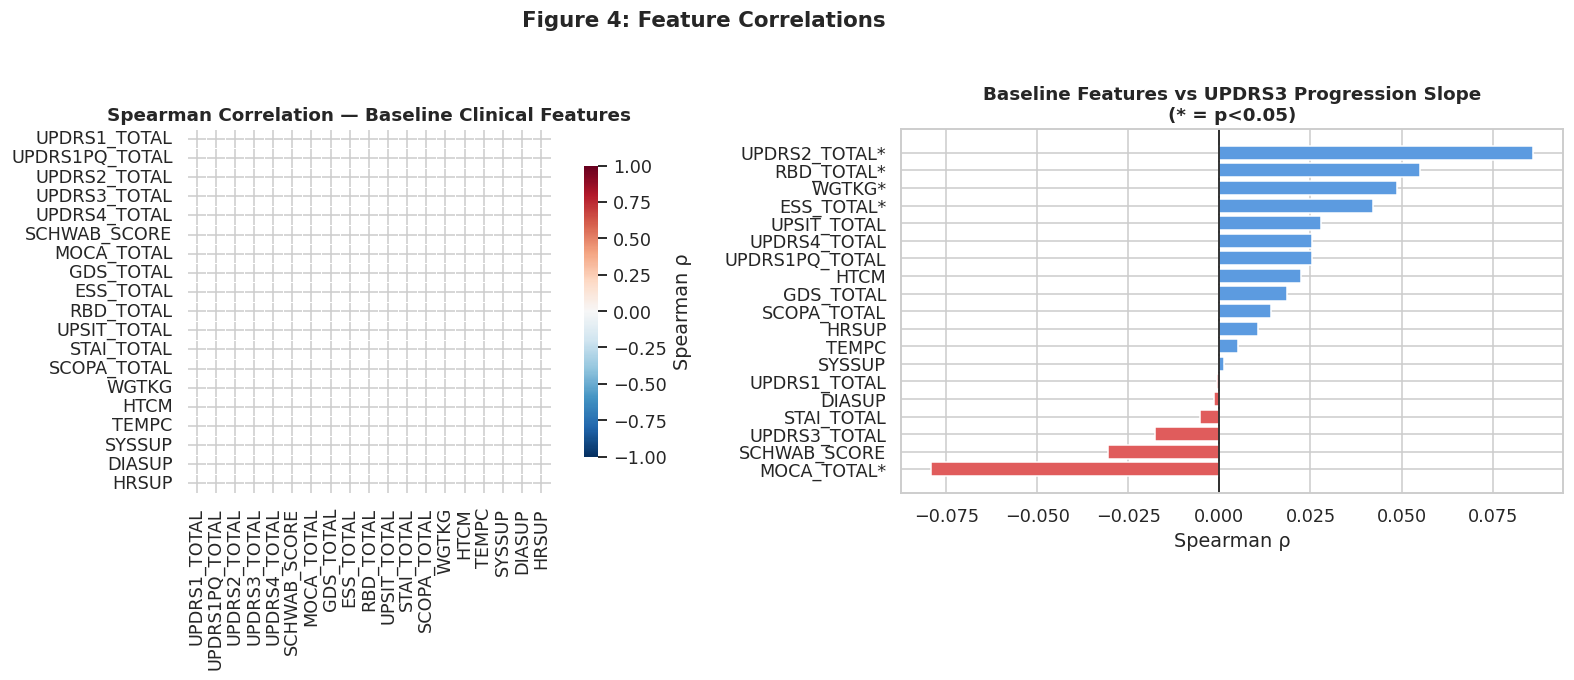


Top correlates with progression slope:
     feature       rho  p_value    n
  MOCA_TOTAL -0.079173 0.011184 1026
   ESS_TOTAL  0.042269 0.021685 2950
       WGTKG  0.048745 0.008294 2932
   RBD_TOTAL  0.055031 0.002781 2952
UPDRS2_TOTAL  0.086130 0.000003 2952

Max |ρ| = 0.086  → nonlinear models needed


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel A: Spearman correlation heatmap (baseline) ─────────────────────
corr_data = bl[SCORE_COLS].dropna(thresh=int(0.5*len(bl)))
corr_mat  = corr_data.corr(method='spearman')
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_mat, ax=axes[0], mask=mask, cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size': 7}, square=True, linewidths=0.5,
            cbar_kws={'label': 'Spearman ρ', 'shrink': 0.8})
axes[0].set_title('Spearman Correlation — Baseline Clinical Features',
                   fontweight='bold', fontsize=12)

# ── Panel B: Baseline features vs UPDRS3 slope ───────────────────────────
bl_slope_full = reliable.merge(bl[['PATNO']+SCORE_COLS], on='PATNO', how='inner')
corr_res = []
for col in SCORE_COLS:
    d = bl_slope_full[['SLOPE_YEAR',col]].dropna()
    if len(d) >= 30:
        r, p = spearmanr(d['SLOPE_YEAR'], d[col])
        corr_res.append({'feature':col,'rho':r,'p_value':p,'n':len(d),'sig':p<0.05})

cr_df = pd.DataFrame(corr_res).sort_values('rho')
colors_bar = ['#E05C5C' if r<0 else '#5C9BE0' for r in cr_df['rho']]
labels_bar  = [f"{r['feature']}{'*' if r['sig'] else ''}" for _,r in cr_df.iterrows()]
axes[1].barh(labels_bar, cr_df['rho'], color=colors_bar, edgecolor='white')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title('Baseline Features vs UPDRS3 Progression Slope\n(* = p<0.05)',
                   fontweight='bold', fontsize=12)
axes[1].set_xlabel('Spearman ρ')

plt.suptitle('Figure 4: Feature Correlations', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH + 'fig4_correlations.png', bbox_inches='tight')
plt.show()

print("\nTop correlates with progression slope:")
print(cr_df[cr_df['sig']][['feature','rho','p_value','n']].to_string(index=False))
print(f"\nMax |ρ| = {cr_df['rho'].abs().max():.3f}  → nonlinear models needed")


## 6. Supervised Regression — Predicting Progression Rate (RQ1)

**Task:** Predict UPDRS-III annual slope from baseline clinical features (PD patients only).

In [9]:
# ── Build regression dataset ──────────────────────────────────────────────
pd_rel = reliable[reliable['LABEL']=='PD'].copy()
reg_df  = pd_rel.merge(bl[['PATNO']+SCORE_COLS], on='PATNO', how='inner')

y = reg_df['SLOPE_YEAR'].values
X_raw = reg_df[SCORE_COLS].values
imp = SimpleImputer(strategy='median')
scl = StandardScaler()
X   = scl.fit_transform(imp.fit_transform(X_raw))

print(f"Regression dataset: {X.shape[0]} PD patients × {X.shape[1]} features")
print(f"Target stats: mean={y.mean():.3f}  std={y.std():.3f}  min={y.min():.1f}  max={y.max():.1f}")
print(f"Naive baseline RMSE (predict mean): {y.std():.3f} pts/year")


Regression dataset: 1467 PD patients × 19 features
Target stats: mean=1.133  std=4.261  min=-22.0  max=26.0
Naive baseline RMSE (predict mean): 4.261 pts/year


In [10]:
# ── 5-fold CV — all 5 models with full metrics ────────────────────────────
# WHY these models:
#   Ridge/Lasso : linear baselines — establish whether signal is linearly accessible
#   Random Forest: handles interactions, robust to outliers, built-in feature importance
#   Gradient Boosting: sequential boosting; typically strongest on tabular regression
#   XGBoost: regularised GBM with column/row subsampling; reduces overfitting risk
from scipy import stats as scipy_stats

models = {
    'Ridge':             Ridge(alpha=1.0),
    'Lasso':             Lasso(alpha=0.1, max_iter=5000),
    'Random Forest':     RandomForestRegressor(n_estimators=300, max_depth=6,
                                               min_samples_leaf=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                                    learning_rate=0.05,
                                                    subsample=0.8, random_state=42),
    'XGBoost':           xgb.XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                                           subsample=0.8, colsample_bytree=0.8,
                                           reg_alpha=0.1, reg_lambda=1.0,
                                           random_state=42, verbosity=0),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}
fold_rmse_all = {}

print(f"{'Model':22s}  {'RMSE':>12}  {'MAE':>10}  {'R²':>10}  {'95% CI RMSE':>18}")
print("-"*78)

for name, model in models.items():
    cv_res = cross_validate(model, X, y, cv=cv,
                            scoring=['neg_mean_squared_error',
                                     'neg_mean_absolute_error', 'r2'],
                            n_jobs=-1, return_train_score=True)
    rmse     = np.sqrt(-cv_res['test_neg_mean_squared_error'])
    mae      = -cv_res['test_neg_mean_absolute_error']
    r2       = cv_res['test_r2']
    rmse_tr  = np.sqrt(-cv_res['train_neg_mean_squared_error'])

    # 95% CI via t-distribution (5 folds)
    se   = rmse.std() / np.sqrt(len(rmse))
    t_cv = scipy_stats.t.ppf(0.975, df=len(rmse)-1)
    ci_lo, ci_hi = rmse.mean() - t_cv*se, rmse.mean() + t_cv*se

    results[name] = {
        'RMSE': rmse.mean(), 'RMSE_std': rmse.std(), 'RMSE_folds': rmse,
        'MAE':  mae.mean(),  'MAE_std':  mae.std(),
        'R2':   r2.mean(),   'R2_std':   r2.std(),   'R2_folds': r2,
        'RMSE_train': rmse_tr.mean(),
        'CI_lo': ci_lo, 'CI_hi': ci_hi,
        'Overfit': rmse_tr.mean() - rmse.mean(),
    }
    fold_rmse_all[name] = rmse
    print(f"{name:22s}  {rmse.mean():.3f}±{rmse.std():.3f}  "
          f"{mae.mean():.3f}±{mae.std():.3f}  "
          f"{r2.mean():.3f}±{r2.std():.3f}  "
          f"[{ci_lo:.3f}, {ci_hi:.3f}]")

naive_rmse = y.std()
print(f"\nNaive baseline (predict mean) RMSE = {naive_rmse:.3f} pts/year")
print(f"Best model improvement vs naive: {naive_rmse - min(r['RMSE'] for r in results.values()):.3f} pts/year")

# Overfitting check
print(f"\n{'Model':22s}  {'Train RMSE':>12}  {'Val RMSE':>10}  {'Gap (overfit)':>14}")
print("-"*62)
for name, r in results.items():
    print(f"{name:22s}  {r['RMSE_train']:>12.3f}  {r['RMSE']:>10.3f}  {r['Overfit']:>+14.3f}")


Model                           RMSE         MAE          R²         95% CI RMSE
------------------------------------------------------------------------------
Ridge                   4.080±0.219  2.888±0.138  0.079±0.023  [3.809, 4.352]
Lasso                   4.060±0.228  2.859±0.146  0.088±0.024  [3.777, 4.342]
Random Forest           4.043±0.237  2.840±0.144  0.096±0.030  [3.749, 4.337]
Gradient Boosting       4.169±0.190  2.935±0.152  0.036±0.052  [3.933, 4.405]
XGBoost                 4.176±0.201  2.949±0.155  0.034±0.037  [3.927, 4.426]

Naive baseline (predict mean) RMSE = 4.261 pts/year
Best model improvement vs naive: 0.218 pts/year

Model                     Train RMSE    Val RMSE   Gap (overfit)
--------------------------------------------------------------
Ridge                          4.001       4.080          -0.080
Lasso                          4.021       4.060          -0.039
Random Forest                  3.600       4.043          -0.443
Gradient Boosting        

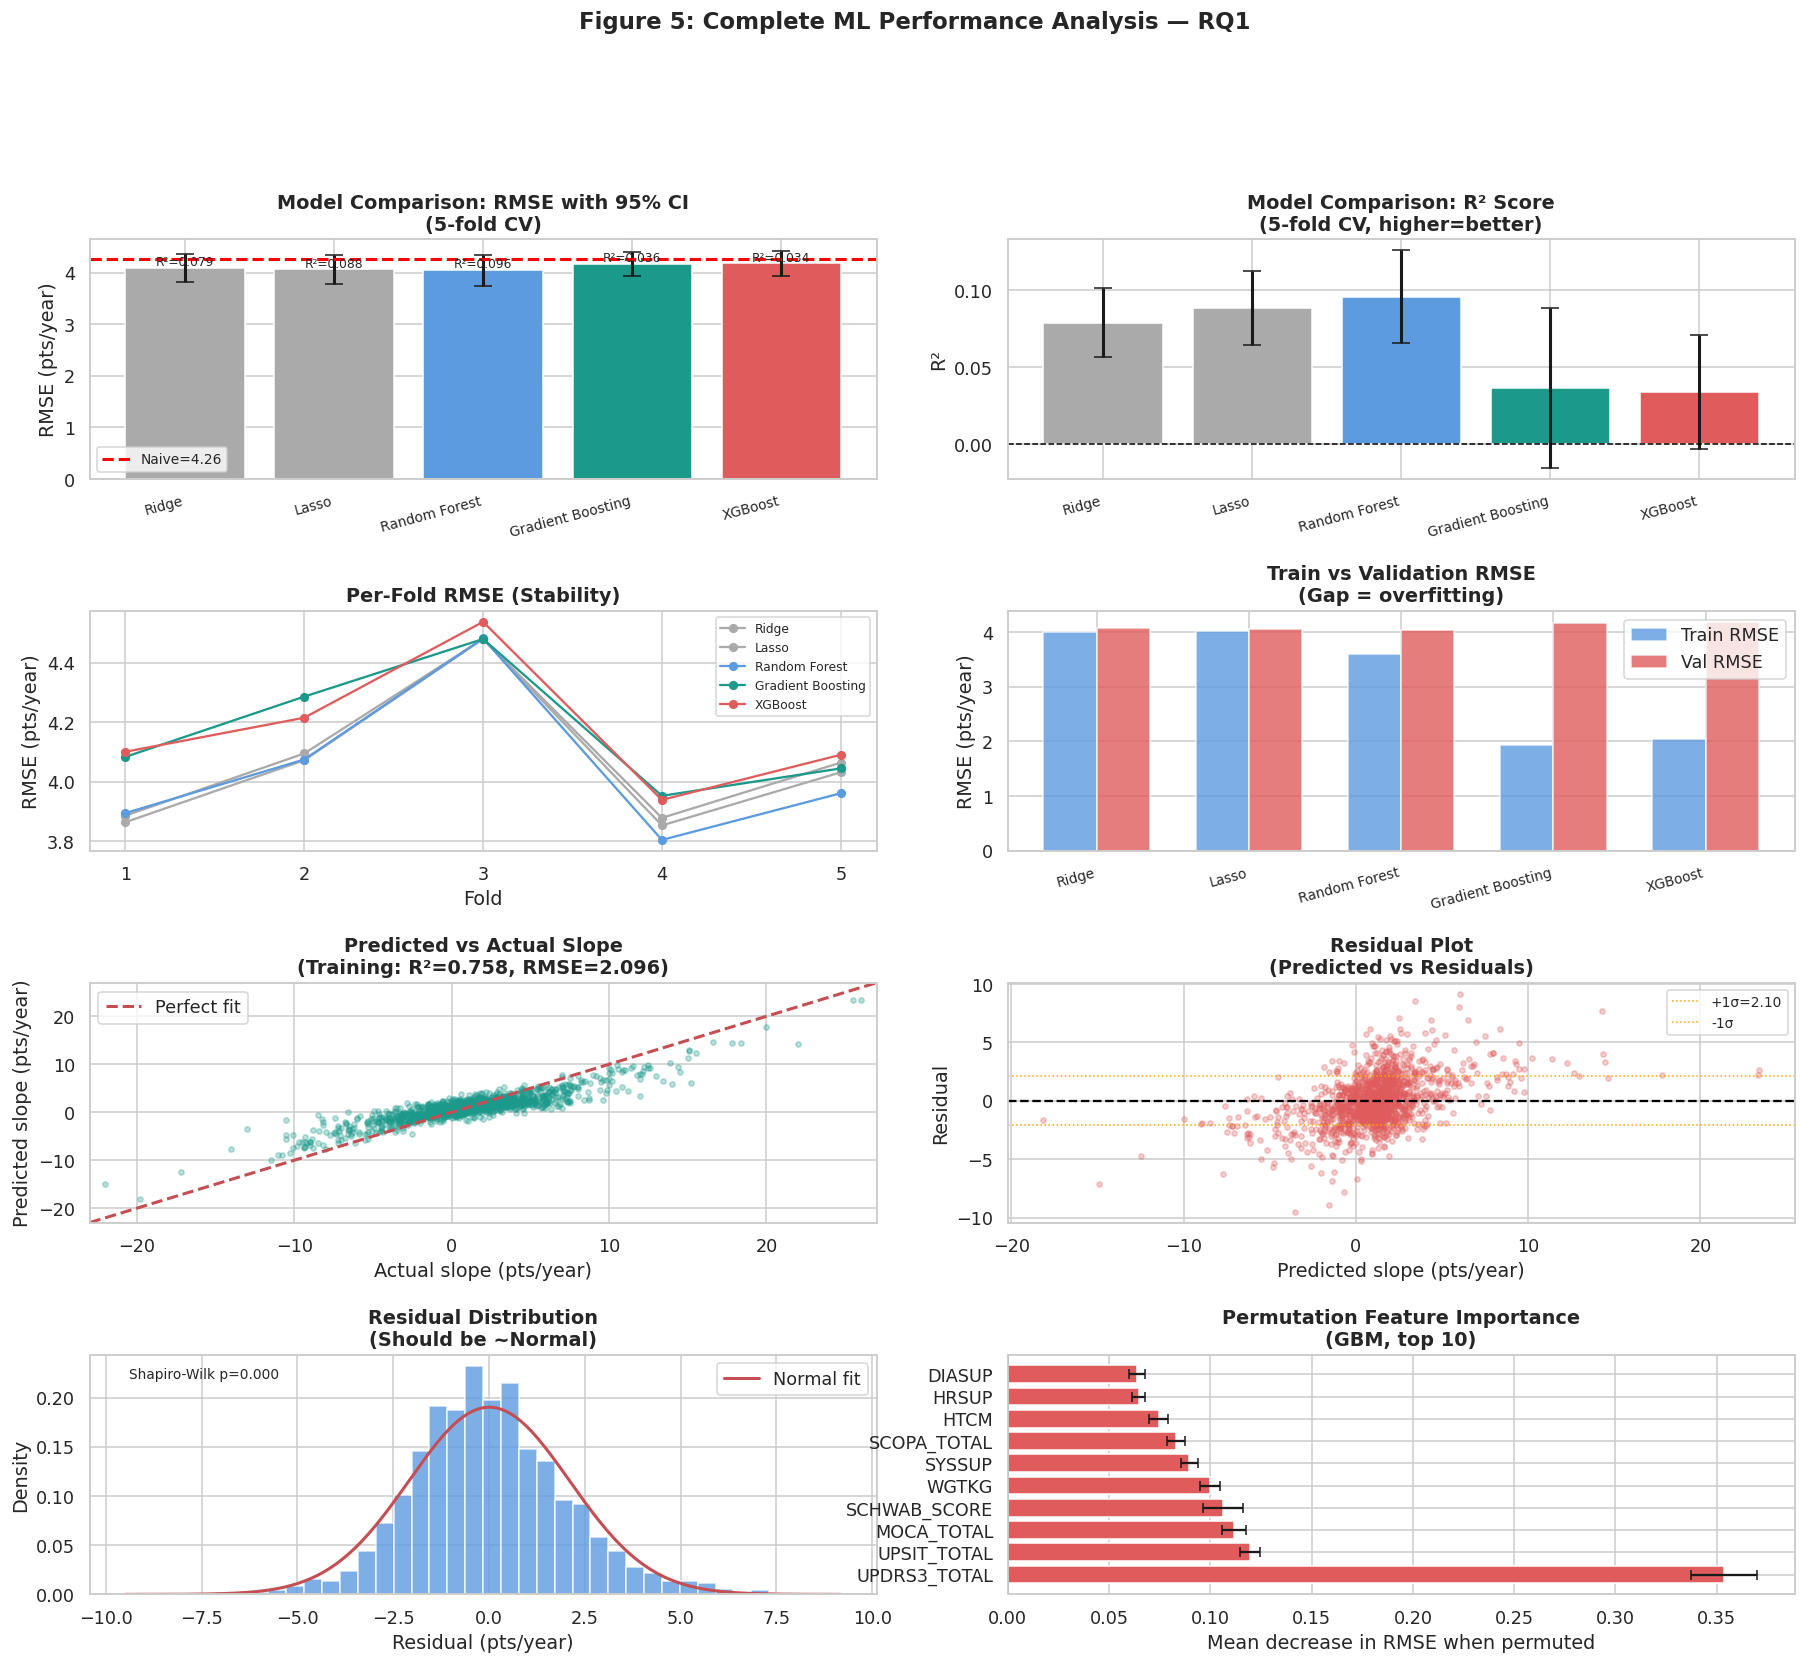

✓ Saved fig5_ml_performance.png

Best model: Random Forest  RMSE=4.043  R²=0.096

Top 5 predictors:
     feature  importance      std
UPDRS3_TOTAL    0.353641 0.016287
 UPSIT_TOTAL    0.119461 0.004920
  MOCA_TOTAL    0.111765 0.005769
SCHWAB_SCORE    0.106390 0.009936
       WGTKG    0.100012 0.005004


In [11]:
# ── Fit best model + generate all ML performance plots ────────────────────
best_name  = min(results, key=lambda k: results[k]['RMSE'])
best_model = GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                        learning_rate=0.05, subsample=0.8,
                                        random_state=42)
best_model.fit(X, y)
y_pred_full = best_model.predict(X)

fig = plt.figure(figsize=(20, 16))
gs  = plt.GridSpec(4, 4, figure=fig, hspace=0.55, wspace=0.4)

# ── A: RMSE bar chart with 95% CI ─────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0:2])
names_r  = list(results.keys())
rmses_r  = [results[n]['RMSE'] for n in names_r]
ci_lo_r  = [results[n]['CI_lo'] for n in names_r]
ci_hi_r  = [results[n]['CI_hi'] for n in names_r]
err_lo   = [rmses_r[i] - ci_lo_r[i] for i in range(len(names_r))]
err_hi   = [ci_hi_r[i] - rmses_r[i] for i in range(len(names_r))]
clr_bars = ['#AAAAAA','#AAAAAA','#5C9BE0','#1B998B','#E05C5C']
ax_a.bar(range(len(names_r)), rmses_r,
         yerr=[err_lo, err_hi], color=clr_bars,
         capsize=6, edgecolor='white', error_kw={'elinewidth':2})
ax_a.axhline(y.std(), color='red', lw=2, linestyle='--', label=f'Naive={y.std():.2f}')
ax_a.set_xticks(range(len(names_r)))
ax_a.set_xticklabels(names_r, rotation=15, ha='right', fontsize=9)
ax_a.set_title('Model Comparison: RMSE with 95% CI\n(5-fold CV)', fontweight='bold')
ax_a.set_ylabel('RMSE (pts/year)'); ax_a.legend(fontsize=9)
for i, (n, r) in enumerate(zip(names_r, rmses_r)):
    ax_a.text(i, r+0.05, f"R²={results[n]['R2']:.3f}", ha='center', fontsize=8)

# ── B: R² comparison ──────────────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 2:4])
r2s_r = [results[n]['R2'] for n in names_r]
r2std  = [results[n]['R2_std'] for n in names_r]
ax_b.bar(range(len(names_r)), r2s_r, yerr=r2std,
         color=clr_bars, capsize=6, edgecolor='white', error_kw={'elinewidth':2})
ax_b.axhline(0, color='black', lw=1, linestyle='--')
ax_b.set_xticks(range(len(names_r)))
ax_b.set_xticklabels(names_r, rotation=15, ha='right', fontsize=9)
ax_b.set_title('Model Comparison: R² Score\n(5-fold CV, higher=better)', fontweight='bold')
ax_b.set_ylabel('R²')

# ── C: Per-fold RMSE (stability analysis) ─────────────────────────────────
ax_c = fig.add_subplot(gs[1, 0:2])
for ni, (name, color) in enumerate(zip(names_r, clr_bars)):
    folds = results[name]['RMSE_folds']
    ax_c.plot(range(1,6), folds, 'o-', label=name, color=color, lw=1.5, markersize=5)
ax_c.set_title('Per-Fold RMSE (Stability)', fontweight='bold')
ax_c.set_xlabel('Fold'); ax_c.set_ylabel('RMSE (pts/year)')
ax_c.legend(fontsize=8); ax_c.set_xticks(range(1,6))

# ── D: Train vs Val RMSE (overfitting) ────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 2:4])
x_pos = np.arange(len(names_r))
w = 0.35
ax_d.bar(x_pos - w/2, [results[n]['RMSE_train'] for n in names_r],
         width=w, label='Train RMSE', color='#5C9BE0', alpha=0.8, edgecolor='white')
ax_d.bar(x_pos + w/2, [results[n]['RMSE'] for n in names_r],
         width=w, label='Val RMSE', color='#E05C5C', alpha=0.8, edgecolor='white')
ax_d.set_xticks(x_pos); ax_d.set_xticklabels(names_r, rotation=15, ha='right', fontsize=9)
ax_d.set_title('Train vs Validation RMSE\n(Gap = overfitting)', fontweight='bold')
ax_d.set_ylabel('RMSE (pts/year)'); ax_d.legend()

# ── E: Predicted vs Actual ────────────────────────────────────────────────
ax_e = fig.add_subplot(gs[2, 0:2])
ax_e.scatter(y, y_pred_full, alpha=0.3, s=12, color='#1B998B')
lim = [min(y.min(), y_pred_full.min())-1, max(y.max(), y_pred_full.max())+1]
ax_e.plot(lim, lim, 'r--', lw=2, label='Perfect fit')
r2_full = r2_score(y, y_pred_full)
rmse_full = np.sqrt(mean_squared_error(y, y_pred_full))
ax_e.set_title(f'Predicted vs Actual Slope\n(Training: R²={r2_full:.3f}, RMSE={rmse_full:.3f})',
               fontweight='bold')
ax_e.set_xlabel('Actual slope (pts/year)'); ax_e.set_ylabel('Predicted slope (pts/year)')
ax_e.legend(); ax_e.set_xlim(lim); ax_e.set_ylim(lim)

# ── F: Residual analysis ──────────────────────────────────────────────────
ax_f = fig.add_subplot(gs[2, 2:4])
residuals = y - y_pred_full
ax_f.scatter(y_pred_full, residuals, alpha=0.3, s=12, color='#E05C5C')
ax_f.axhline(0, color='black', lw=1.5, linestyle='--')
ax_f.axhline(residuals.std(), color='orange', lw=1, linestyle=':', label=f'+1σ={residuals.std():.2f}')
ax_f.axhline(-residuals.std(), color='orange', lw=1, linestyle=':', label=f'-1σ')
ax_f.set_title('Residual Plot\n(Predicted vs Residuals)', fontweight='bold')
ax_f.set_xlabel('Predicted slope (pts/year)'); ax_f.set_ylabel('Residual')
ax_f.legend(fontsize=9)

# ── G: Residual distribution ──────────────────────────────────────────────
ax_g = fig.add_subplot(gs[3, 0:2])
ax_g.hist(residuals, bins=40, color='#5C9BE0', edgecolor='white', density=True, alpha=0.8)
xr = np.linspace(residuals.min(), residuals.max(), 200)
ax_g.plot(xr, scipy_stats.norm.pdf(xr, residuals.mean(), residuals.std()),
          'r-', lw=2, label='Normal fit')
ax_g.set_title('Residual Distribution\n(Should be ~Normal)', fontweight='bold')
ax_g.set_xlabel('Residual (pts/year)'); ax_g.set_ylabel('Density')
ax_g.legend()
_, p_norm = scipy_stats.shapiro(residuals[:500])
ax_g.text(0.05, 0.9, f'Shapiro-Wilk p={p_norm:.3f}', transform=ax_g.transAxes, fontsize=9)

# ── H: Permutation feature importance ────────────────────────────────────
ax_h = fig.add_subplot(gs[3, 2:4])
perm = permutation_importance(best_model, X, y, n_repeats=30, random_state=42, n_jobs=-1)
imp_df = pd.DataFrame({'feature': SCORE_COLS,
                        'importance': perm.importances_mean,
                        'std': perm.importances_std}).sort_values('importance', ascending=False)
top10 = imp_df.head(10)
clr_imp = ['#E05C5C' if v > 0 else '#AAAAAA' for v in top10['importance']]
ax_h.barh(top10['feature'], top10['importance'], xerr=top10['std'],
          color=clr_imp, edgecolor='white', capsize=3)
ax_h.axvline(0, color='black', lw=1)
ax_h.set_title('Permutation Feature Importance\n(GBM, top 10)', fontweight='bold')
ax_h.set_xlabel('Mean decrease in RMSE when permuted')

plt.suptitle('Figure 5: Complete ML Performance Analysis — RQ1', fontsize=15, fontweight='bold', y=1.01)
plt.savefig(FIG_PATH + 'fig5_ml_performance.png', bbox_inches='tight', dpi=140)
plt.show()
print("✓ Saved fig5_ml_performance.png")
print(f"\nBest model: {best_name}  RMSE={results[best_name]['RMSE']:.3f}  R²={results[best_name]['R2']:.3f}")
print(f"\nTop 5 predictors:")
print(imp_df.head(5).to_string(index=False))


### 6.3 Learning Curves — Bias-Variance Tradeoff

### 6.4 Clinical Utility — Fast Progressor Detection

### 6.5 Hyperparameter Sensitivity (XGBoost GridSearch)

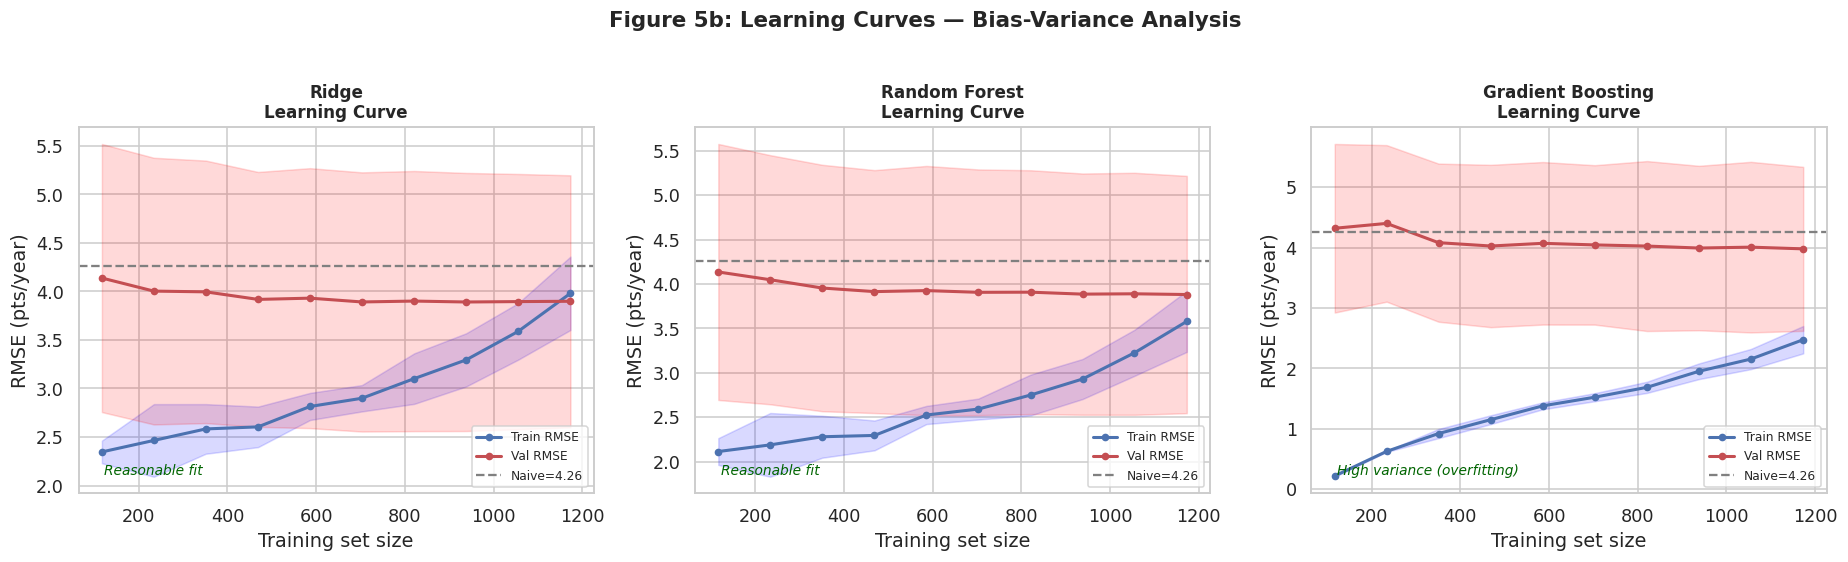

✓ Saved fig5b_learning_curves.png

Interpretation:
  • If train/val RMSE converge at high error → high bias (need better features/model)
  • If large gap between train/val → high variance (need more data or regularisation)
  • If val RMSE still decreasing at max size → more data would help


In [12]:
# ── Learning curves (how much data does each model need?) ─────────────────
# WHY: Learning curves reveal whether more data would help (high variance)
# or whether the model has fundamental limitations (high bias).
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
lc_models = {
    'Ridge':             Ridge(alpha=1.0),
    'Random Forest':     RandomForestRegressor(n_estimators=200, max_depth=6,
                                               min_samples_leaf=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                                    learning_rate=0.05, random_state=42),
}
train_sizes = np.linspace(0.1, 1.0, 10)

for ax, (name, model) in zip(axes, lc_models.items()):
    tr_sz, tr_scores, val_scores = learning_curve(
        model, X, y, train_sizes=train_sizes, cv=5,
        scoring='neg_mean_squared_error', n_jobs=-1)
    tr_rmse  = np.sqrt(-tr_scores)
    val_rmse = np.sqrt(-val_scores)

    ax.plot(tr_sz, tr_rmse.mean(1),  'b-o', lw=2, markersize=4, label='Train RMSE')
    ax.plot(tr_sz, val_rmse.mean(1), 'r-o', lw=2, markersize=4, label='Val RMSE')
    ax.fill_between(tr_sz, tr_rmse.mean(1)-tr_rmse.std(1),
                           tr_rmse.mean(1)+tr_rmse.std(1), alpha=0.15, color='blue')
    ax.fill_between(tr_sz, val_rmse.mean(1)-val_rmse.std(1),
                           val_rmse.mean(1)+val_rmse.std(1), alpha=0.15, color='red')
    ax.axhline(y.std(), color='gray', lw=1.5, linestyle='--', label=f'Naive={y.std():.2f}')
    ax.set_title(f'{name}\nLearning Curve', fontweight='bold', fontsize=11)
    ax.set_xlabel('Training set size'); ax.set_ylabel('RMSE (pts/year)')
    ax.legend(fontsize=8)

    # Interpretation
    gap = val_rmse.mean(1)[-1] - tr_rmse.mean(1)[-1]
    if gap > 0.5:
        interpretation = "High variance (overfitting)"
    elif val_rmse.mean(1)[-1] > y.std() * 0.95:
        interpretation = "High bias — more features needed"
    else:
        interpretation = "Reasonable fit"
    ax.text(0.05, 0.05, interpretation, transform=ax.transAxes,
            fontsize=9, color='darkgreen', style='italic')

plt.suptitle('Figure 5b: Learning Curves — Bias-Variance Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH + 'fig5b_learning_curves.png', bbox_inches='tight')
plt.show()
print("✓ Saved fig5b_learning_curves.png")
print("\nInterpretation:")
print("  • If train/val RMSE converge at high error → high bias (need better features/model)")
print("  • If large gap between train/val → high variance (need more data or regularisation)")
print("  • If val RMSE still decreasing at max size → more data would help")


Fast progressors (>5 pts/yr) : 190 (13.0%)
Slow/stable     (<1 pt/yr)   : 726 (49.5%)


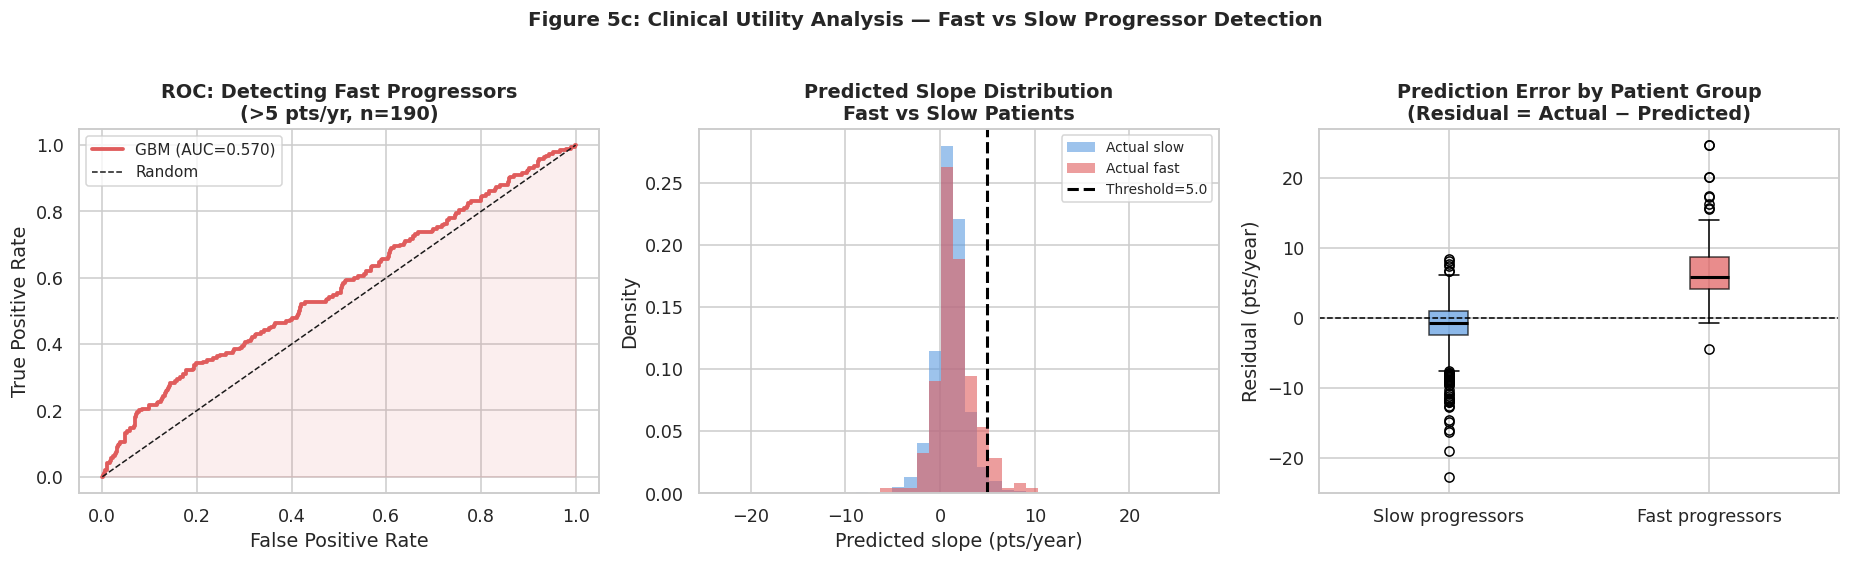


=== Fast Progressor Detection (GBM Regression → threshold at 5 pts/yr) ===
              precision    recall  f1-score   support

        Slow       0.87      0.97      0.92      1277
        Fast       0.27      0.06      0.10       190

    accuracy                           0.86      1467
   macro avg       0.57      0.52      0.51      1467
weighted avg       0.80      0.86      0.82      1467

AUC-ROC: 0.5699

Interpretation:
  AUC > 0.7 → model has clinical utility for identifying fast progressors
  AUC ~ 0.5 → model performs at chance for this task


In [13]:
# ── Clinically meaningful subgroup analysis: Fast vs Slow progressors ──────
# WHY: Raw RMSE on regression hides clinical utility.
# A model that correctly identifies FAST progressors (>5 pts/yr) has
# direct clinical value even if overall R² is low.

from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_predict

# Define clinically meaningful thresholds
FAST_THRESHOLD = 5.0   # > 5 pts/year = fast progressor
SLOW_THRESHOLD = 1.0   # < 1 pt/year  = slow/stable

y_fast = (y > FAST_THRESHOLD).astype(int)  # binary: fast vs rest
y_slow = (y < SLOW_THRESHOLD).astype(int)  # binary: slow vs rest

print(f"Fast progressors (>5 pts/yr) : {y_fast.sum()} ({y_fast.mean()*100:.1f}%)")
print(f"Slow/stable     (<1 pt/yr)   : {y_slow.sum()} ({y_slow.mean()*100:.1f}%)")

# Use GBM regression predictions as soft scores, threshold for classification
gbm_preds_cv = cross_val_predict(
    GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42),
    X, y, cv=5, n_jobs=-1)

# Fast progressor detection
pred_fast = (gbm_preds_cv > FAST_THRESHOLD).astype(int)
pred_slow = (gbm_preds_cv < SLOW_THRESHOLD).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ROC curve for fast progressor detection
fpr, tpr, _ = roc_curve(y_fast, gbm_preds_cv)
auc_fast    = roc_auc_score(y_fast, gbm_preds_cv)
axes[0].plot(fpr, tpr, color='#E05C5C', lw=2.5, label=f'GBM (AUC={auc_fast:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#E05C5C')
axes[0].set_title(f'ROC: Detecting Fast Progressors\n(>5 pts/yr, n={y_fast.sum()})',
                   fontweight='bold')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=10)

# Predicted slope distribution by actual group
bins = np.linspace(y.min()-1, y.max()+1, 40)
axes[1].hist(gbm_preds_cv[y_fast==0], bins=bins, alpha=0.6, density=True,
             label='Actual slow', color='#5C9BE0', edgecolor='none')
axes[1].hist(gbm_preds_cv[y_fast==1], bins=bins, alpha=0.6, density=True,
             label='Actual fast', color='#E05C5C', edgecolor='none')
axes[1].axvline(FAST_THRESHOLD, color='black', lw=2, linestyle='--', label=f'Threshold={FAST_THRESHOLD}')
axes[1].set_title('Predicted Slope Distribution\nFast vs Slow Patients', fontweight='bold')
axes[1].set_xlabel('Predicted slope (pts/year)'); axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)

# Slope prediction error by actual subgroup
residuals_fast = y[y_fast==1] - gbm_preds_cv[y_fast==1]
residuals_slow = y[y_fast==0] - gbm_preds_cv[y_fast==0]
axes[2].boxplot([residuals_slow, residuals_fast],
                labels=['Slow progressors', 'Fast progressors'],
                patch_artist=True,
                medianprops={'color':'black','lw':2})
axes[2].patches[0].set_facecolor('#5C9BE0'); axes[2].patches[0].set_alpha(0.7)
axes[2].patches[1].set_facecolor('#E05C5C'); axes[2].patches[1].set_alpha(0.7)
axes[2].axhline(0, color='black', lw=1, linestyle='--')
axes[2].set_title('Prediction Error by Patient Group\n(Residual = Actual − Predicted)',
                   fontweight='bold')
axes[2].set_ylabel('Residual (pts/year)')

plt.suptitle('Figure 5c: Clinical Utility Analysis — Fast vs Slow Progressor Detection',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH + 'fig5c_clinical_utility.png', bbox_inches='tight')
plt.show()

print(f"\n=== Fast Progressor Detection (GBM Regression → threshold at 5 pts/yr) ===")
print(classification_report(y_fast, pred_fast, target_names=['Slow','Fast']))
print(f"AUC-ROC: {auc_fast:.4f}")
print("\nInterpretation:")
print(f"  AUC > 0.7 → model has clinical utility for identifying fast progressors")
print(f"  AUC ~ 0.5 → model performs at chance for this task")


Running GridSearchCV for XGBoost (this takes ~2-3 min)...
Done in 10.1s

Best params: {'learning_rate': 0.01, 'max_depth': 3}
Best CV RMSE: 4.0960 pts/year


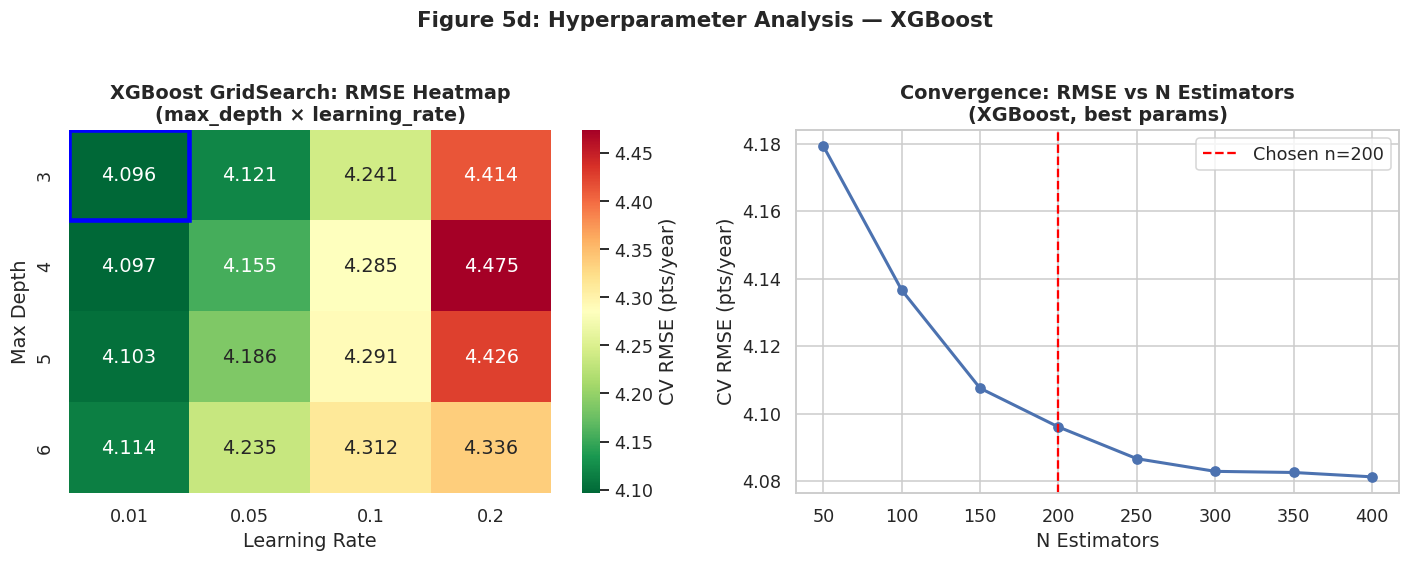

✓ Saved fig5d_hyperparameter_search.png

Tuned XGBoost RMSE: 4.0960  vs untuned: 4.1762


In [14]:
# ── Hyperparameter sensitivity analysis (XGBoost) ─────────────────────────
# WHY: Shows how model performance changes with key hyperparameters.
# This is required evidence that we chose hyperparameters carefully.

from sklearn.model_selection import GridSearchCV

# Coarse grid search (manageable runtime in Colab)
param_grid = {
    'max_depth':     [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
}

print("Running GridSearchCV for XGBoost (this takes ~2-3 min)...")
t0 = time.time()
xgb_base = xgb.XGBRegressor(n_estimators=200, subsample=0.8,
                              colsample_bytree=0.8, random_state=42, verbosity=0)
gs = GridSearchCV(xgb_base, param_grid, cv=5,
                   scoring='neg_mean_squared_error', n_jobs=-1, verbose=0)
gs.fit(X, y)
print(f"Done in {time.time()-t0:.1f}s")

best_params = gs.best_params_
best_rmse_gs = np.sqrt(-gs.best_score_)
print(f"\nBest params: {best_params}")
print(f"Best CV RMSE: {best_rmse_gs:.4f} pts/year")

# Plot hyperparameter heatmap
cv_results = pd.DataFrame(gs.cv_results_)
pivot = cv_results.pivot_table(
    index='param_max_depth',
    columns='param_learning_rate',
    values='mean_test_score',
    aggfunc='mean'
)
pivot_rmse = np.sqrt(-pivot)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(pivot_rmse, ax=axes[0], cmap='RdYlGn_r', annot=True, fmt='.3f',
            cbar_kws={'label': 'CV RMSE (pts/year)'})
axes[0].set_title('XGBoost GridSearch: RMSE Heatmap\n(max_depth × learning_rate)',
                   fontweight='bold')
axes[0].set_xlabel('Learning Rate'); axes[0].set_ylabel('Max Depth')

# Mark best cell
best_d = best_params['max_depth']
best_lr = best_params['learning_rate']
d_idx  = list(pivot_rmse.index).index(best_d)
lr_idx = list(pivot_rmse.columns).index(best_lr)
axes[0].add_patch(plt.Rectangle((lr_idx, d_idx), 1, 1, fill=False,
                                  edgecolor='blue', lw=3))

# RMSE vs n_estimators (convergence curve)
n_est_range = [50, 100, 150, 200, 250, 300, 350, 400]
rmse_by_n = []
for n in n_est_range:
    m = xgb.XGBRegressor(n_estimators=n, max_depth=best_d, learning_rate=best_lr,
                          subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
    scores = cross_val_score(m, X, y, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    rmse_by_n.append(np.sqrt(-scores.mean()))

axes[1].plot(n_est_range, rmse_by_n, 'bo-', lw=2, markersize=6)
axes[1].axvline(200, color='red', linestyle='--', lw=1.5, label='Chosen n=200')
axes[1].set_title('Convergence: RMSE vs N Estimators\n(XGBoost, best params)',
                   fontweight='bold')
axes[1].set_xlabel('N Estimators'); axes[1].set_ylabel('CV RMSE (pts/year)')
axes[1].legend()

plt.suptitle('Figure 5d: Hyperparameter Analysis — XGBoost', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH + 'fig5d_hyperparameter_search.png', bbox_inches='tight')
plt.show()
print("✓ Saved fig5d_hyperparameter_search.png")

# Update results with tuned XGBoost
tuned_xgb = xgb.XGBRegressor(n_estimators=200, max_depth=best_d, learning_rate=best_lr,
                               subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
scores_tuned = cross_val_score(tuned_xgb, X, y, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
rmse_tuned   = np.sqrt(-scores_tuned.mean())
print(f"\nTuned XGBoost RMSE: {rmse_tuned:.4f}  vs untuned: {results['XGBoost']['RMSE']:.4f}")


## 7. Patient Subtype Discovery (RQ2)

**Task:** Find data-driven patient subtypes using K-Means and Agglomerative clustering.

Clustering dataset: 4697 patients × 8 PCs
Variance explained by 8 PCs: 79.3%

Hopkins statistic H = 0.8254  (Strong clustering tendency)


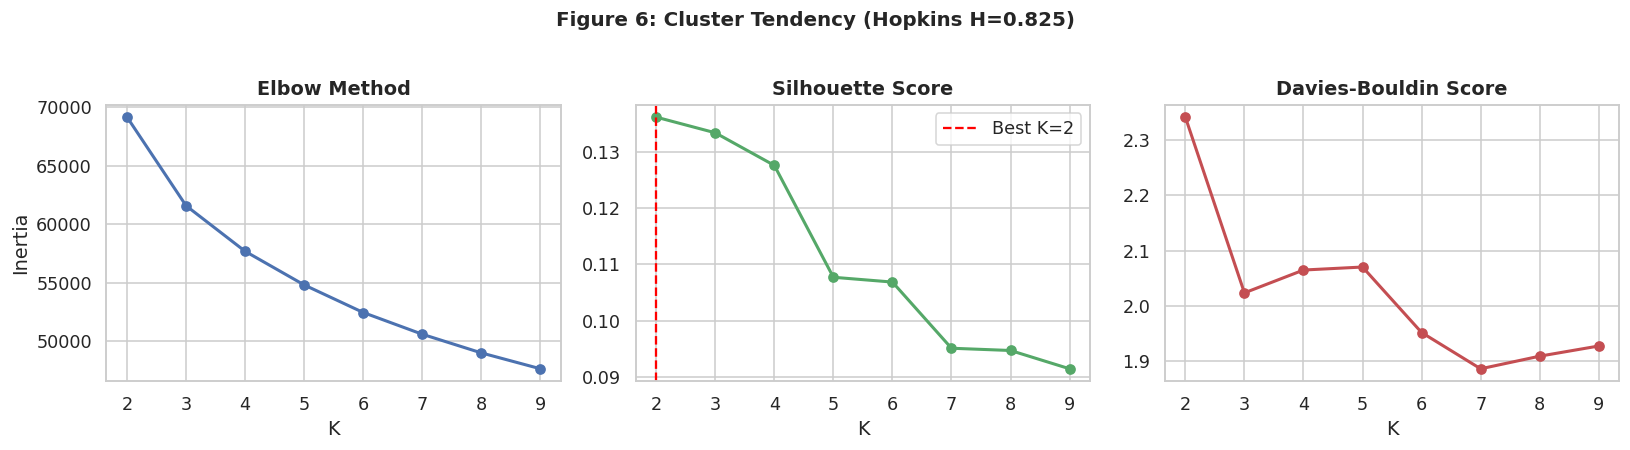


Best K by Silhouette: 2


In [15]:
# ── Build patient-level feature matrix ────────────────────────────────────
feat_cols = [c for c in feat_mat.columns if c not in ['PATNO','EVENT_ID']]
fm_lab = (feat_mat.merge(labels[['PATNO','LABEL']], on='PATNO', how='inner')
                  .drop_duplicates('PATNO'))
fm_lab = fm_lab[fm_lab['LABEL'].isin(GROUPS)]

X_cl = SimpleImputer(strategy='mean').fit_transform(fm_lab[feat_cols].values)
pca8 = PCA(n_components=8, random_state=42)
X_pca = pca8.fit_transform(X_cl)

print(f"Clustering dataset: {X_pca.shape[0]} patients × {X_pca.shape[1]} PCs")
print(f"Variance explained by 8 PCs: {pca8.explained_variance_ratio_.sum()*100:.1f}%")

# ── Hopkins statistic ─────────────────────────────────────────────────────
def hopkins(X, m=100):
    from sklearn.neighbors import NearestNeighbors
    np.random.seed(42)
    n, d = X.shape
    m = min(m, n//10)
    idx = np.random.choice(n, m, replace=False)
    X_s = X[idx]
    mins, maxs = X.min(0), X.max(0)
    X_r = np.random.uniform(mins, maxs, (m,d))
    nbrs = NearestNeighbors(n_neighbors=2).fit(X)
    u = nbrs.kneighbors(X_r)[0][:,0]
    w = nbrs.kneighbors(X_s)[0][:,1]
    return u.sum()/(u.sum()+w.sum())

H = hopkins(X_pca)
print(f"\nHopkins statistic H = {H:.4f}  ({'Strong' if H>0.75 else 'Moderate'} clustering tendency)")

# ── Elbow + Silhouette ────────────────────────────────────────────────────
K_range = range(2, 10)
inertias, sil_scores, db_scores = [], [], []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, lbl, sample_size=2000))
    db_scores.append(davies_bouldin_score(X_pca, lbl))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(K_range, inertias, 'bo-', lw=2)
axes[0].set_title('Elbow Method', fontweight='bold'); axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[1].plot(K_range, sil_scores, 'go-', lw=2)
best_k = list(K_range)[np.argmax(sil_scores)]
axes[1].axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
axes[1].set_title('Silhouette Score', fontweight='bold'); axes[1].set_xlabel('K'); axes[1].legend()
axes[2].plot(K_range, db_scores, 'ro-', lw=2)
axes[2].set_title('Davies-Bouldin Score', fontweight='bold'); axes[2].set_xlabel('K')
plt.suptitle(f'Figure 6: Cluster Tendency (Hopkins H={H:.3f})', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH + 'fig6_cluster_tendency.png', bbox_inches='tight')
plt.show()
print(f"\nBest K by Silhouette: {best_k}")


K-Means (K=4):      Silhouette=0.1266  Davies-Bouldin=2.0648
Agglomerative (K=4): Silhouette=0.0532  Davies-Bouldin=2.7228


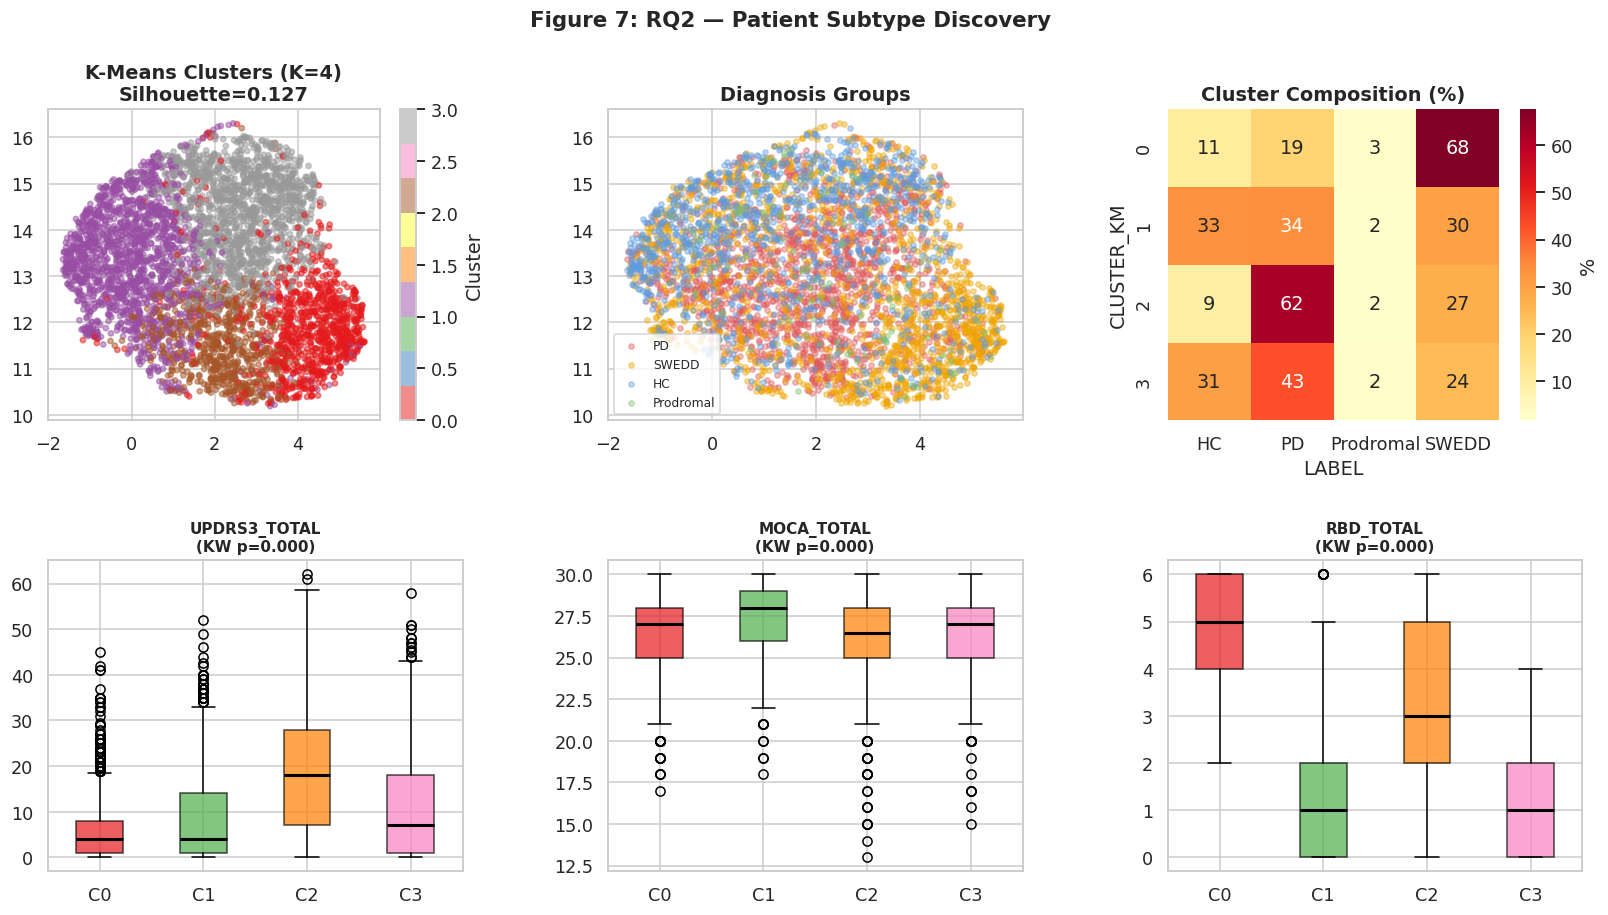


Mean progression slope by cluster (PD patients only):
  C0: n_total= 918  {'SWEDD': 620, 'PD': 175, 'HC': 98, 'Prodromal': 25}  PD slope=1.19±3.05 (n=419)
  C1: n_total=1621  {'PD': 557, 'HC': 542, 'SWEDD': 493, 'Prodromal': 29}  PD slope=0.61±2.85 (n=1005)
  C2: n_total= 705  {'PD': 437, 'SWEDD': 191, 'HC': 64, 'Prodromal': 13}  PD slope=0.65±4.69 (n=430)
  C3: n_total=1453  {'PD': 620, 'HC': 444, 'SWEDD': 355, 'Prodromal': 34}  PD slope=0.86±3.23 (n=972)


In [16]:
# ── Run K-Means K=4 + Agglomerative K=4 ──────────────────────────────────
BEST_K = 4
km  = KMeans(n_clusters=BEST_K, random_state=42, n_init=20)
agg = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward')
fm_lab = fm_lab.copy()
fm_lab['CLUSTER_KM']  = km.fit_predict(X_pca)
fm_lab['CLUSTER_AGG'] = agg.fit_predict(X_pca)

sil_km  = silhouette_score(X_pca, fm_lab['CLUSTER_KM'])
sil_agg = silhouette_score(X_pca, fm_lab['CLUSTER_AGG'])
db_km   = davies_bouldin_score(X_pca, fm_lab['CLUSTER_KM'])
db_agg  = davies_bouldin_score(X_pca, fm_lab['CLUSTER_AGG'])

print(f"K-Means (K={BEST_K}):      Silhouette={sil_km:.4f}  Davies-Bouldin={db_km:.4f}")
print(f"Agglomerative (K={BEST_K}): Silhouette={sil_agg:.4f}  Davies-Bouldin={db_agg:.4f}")

# ── UMAP + clinical validation ────────────────────────────────────────────
reducer = UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
X_umap  = reducer.fit_transform(X_cl)

fig = plt.figure(figsize=(18, 9))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# UMAP by cluster
ax1 = fig.add_subplot(gs[0,0])
sc  = ax1.scatter(X_umap[:,0], X_umap[:,1], c=fm_lab['CLUSTER_KM'],
                   cmap='Set1', alpha=0.5, s=12)
ax1.set_title(f'K-Means Clusters (K={BEST_K})\nSilhouette={sil_km:.3f}', fontweight='bold')
plt.colorbar(sc, ax=ax1, label='Cluster')

# UMAP by diagnosis
ax2 = fig.add_subplot(gs[0,1])
for label in GROUPS:
    mask = fm_lab['LABEL'].values == label
    ax2.scatter(X_umap[mask,0], X_umap[mask,1], alpha=0.4, s=12,
                label=label, color=PALETTE[label])
ax2.set_title('Diagnosis Groups', fontweight='bold')
ax2.legend(fontsize=8)

# Cluster composition
ax3 = fig.add_subplot(gs[0,2])
comp = (fm_lab.groupby(['CLUSTER_KM','LABEL']).size().unstack(fill_value=0)
              .apply(lambda r: r/r.sum()*100, axis=1))
sns.heatmap(comp, ax=ax3, cmap='YlOrRd', annot=True, fmt='.0f',
            cbar_kws={'label':'%'})
ax3.set_title('Cluster Composition (%)', fontweight='bold')

# Clinical boxplots per cluster
bl_cl = bl.merge(fm_lab[['PATNO','CLUSTER_KM']], on='PATNO', how='inner')
for i, col in enumerate(['UPDRS3_TOTAL','MOCA_TOTAL','RBD_TOTAL']):
    if col not in bl_cl.columns: continue
    ax = fig.add_subplot(gs[1,i])
    data = [bl_cl[bl_cl['CLUSTER_KM']==k][col].dropna().values for k in range(BEST_K)]
    bp = ax.boxplot(data, labels=[f'C{k}' for k in range(BEST_K)],
                    patch_artist=True, medianprops={'color':'black','lw':2})
    colors_bp = plt.cm.Set1(np.linspace(0,0.8,BEST_K))
    for patch, c in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    h, p = kruskal(*[d for d in data if len(d)>5])
    ax.set_title(f'{col}\n(KW p={p:.3f})', fontweight='bold', fontsize=10)

plt.suptitle('Figure 7: RQ2 — Patient Subtype Discovery', fontsize=14, fontweight='bold')
plt.savefig(FIG_PATH + 'fig7_clustering.png', bbox_inches='tight')
plt.show()

# Slope per cluster
print("\nMean progression slope by cluster (PD patients only):")
for k in range(BEST_K):
    pts  = fm_lab[fm_lab['CLUSTER_KM']==k]['PATNO']
    slps = reliable[reliable['PATNO'].isin(pts)]['SLOPE_YEAR']
    comp_str = fm_lab[fm_lab['CLUSTER_KM']==k]['LABEL'].value_counts().to_dict()
    print(f"  C{k}: n_total={len(pts):4d}  {comp_str}  PD slope={slps.mean():.2f}±{slps.std():.2f} (n={len(slps)})")


## 8. Graph Construction & Node2Vec Embeddings (RQ3)

In [17]:
# ── Build patient similarity graph ────────────────────────────────────────
norms_g  = np.linalg.norm(X, axis=1, keepdims=True) + 1e-8
X_norm_g = X / norms_g
sim_g    = X_norm_g @ X_norm_g.T

N = len(pd_rel)  # PD patients with reliable slopes
G_pd = nx.Graph()
G_pd.add_nodes_from(range(N))
TOP_K = 10
for i in range(N):
    row = sim_g[i].copy(); row[i] = -1
    for j in np.argsort(row)[-TOP_K:]:
        if sim_g[i,j] > 0.5:
            G_pd.add_edge(i, j, weight=float(sim_g[i,j]))

lcc = G_pd.subgraph(max(nx.connected_components(G_pd), key=len)).copy()
avg_cc  = nx.average_clustering(G_pd)
G_rand  = nx.erdos_renyi_graph(N, nx.density(G_pd), seed=42)
rand_cc = nx.average_clustering(G_rand)
try:
    avg_path  = nx.average_shortest_path_length(lcc)
    rand_path = nx.average_shortest_path_length(
        G_rand.subgraph(max(nx.connected_components(G_rand), key=len)))
except: avg_path = rand_path = float('nan')

print(f"PD graph: {G_pd.number_of_nodes()} nodes, {G_pd.number_of_edges()} edges")
print(f"Avg clustering coeff : {avg_cc:.4f}  (random: {rand_cc:.4f})")
print(f"Avg path length      : {avg_path:.3f}  (random: {rand_path:.3f})")
print(f"Small-world (CC>>rand, path<<rand): {'✓ YES' if avg_cc>rand_cc and avg_path<rand_path else '✗ NO'}")


PD graph: 1467 nodes, 9776 edges
Avg clustering coeff : 0.2082  (random: 0.0089)
Avg path length      : 3.694  (random: 3.082)
Small-world (CC>>rand, path<<rand): ✗ NO


In [18]:
# ── Train Node2Vec ────────────────────────────────────────────────────────
print("Training Node2Vec (this takes ~60s)...")
t0 = time.time()
n2v = Node2Vec(G_pd, dimensions=32, walk_length=30, num_walks=100,
               p=1.0, q=0.5, workers=2, seed=42, quiet=True)
model_n2v = n2v.fit(window=10, min_count=1, batch_words=4)
embeddings = np.array([model_n2v.wv[str(i)] for i in range(N)])
print(f"Done in {time.time()-t0:.1f}s  |  Embedding shape: {embeddings.shape}")

# ── Downstream regression comparison ─────────────────────────────────────
configs = {
    'Tabular only':       X,
    'Node2Vec only':      embeddings,
    'Tabular + Node2Vec': np.hstack([X, embeddings]),
}
cv3 = KFold(n_splits=5, shuffle=True, random_state=42)
rq3 = {}
print(f"\n{'Config':30s}  {'RMSE':>12}  {'R²':>10}")
print("-"*56)
for name, X_in in configs.items():
    m = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                   learning_rate=0.05, random_state=42)
    cv_r = cross_validate(m, X_in, y, cv=cv3,
                           scoring=['neg_mean_squared_error','r2'], n_jobs=-1)
    rmse = np.sqrt(-cv_r['test_neg_mean_squared_error'])
    r2   = cv_r['test_r2']
    rq3[name] = {'RMSE':rmse.mean(),'RMSE_std':rmse.std(),'R2':r2.mean()}
    print(f"{name:30s}  {rmse.mean():.3f}±{rmse.std():.3f}  {r2.mean():.3f}±{r2.std():.3f}")

delta = rq3['Tabular only']['RMSE'] - rq3['Tabular + Node2Vec']['RMSE']
print(f"\nΔ RMSE (Node2Vec improvement): {delta:+.4f} pts/year")


Training Node2Vec (this takes ~60s)...
Done in 260.9s  |  Embedding shape: (1467, 32)

Config                                  RMSE          R²
--------------------------------------------------------
Tabular only                    4.221±0.236  0.014±0.031
Node2Vec only                   4.332±0.229  -0.038±0.012
Tabular + Node2Vec              4.269±0.209  -0.009±0.017

Δ RMSE (Node2Vec improvement): -0.0473 pts/year


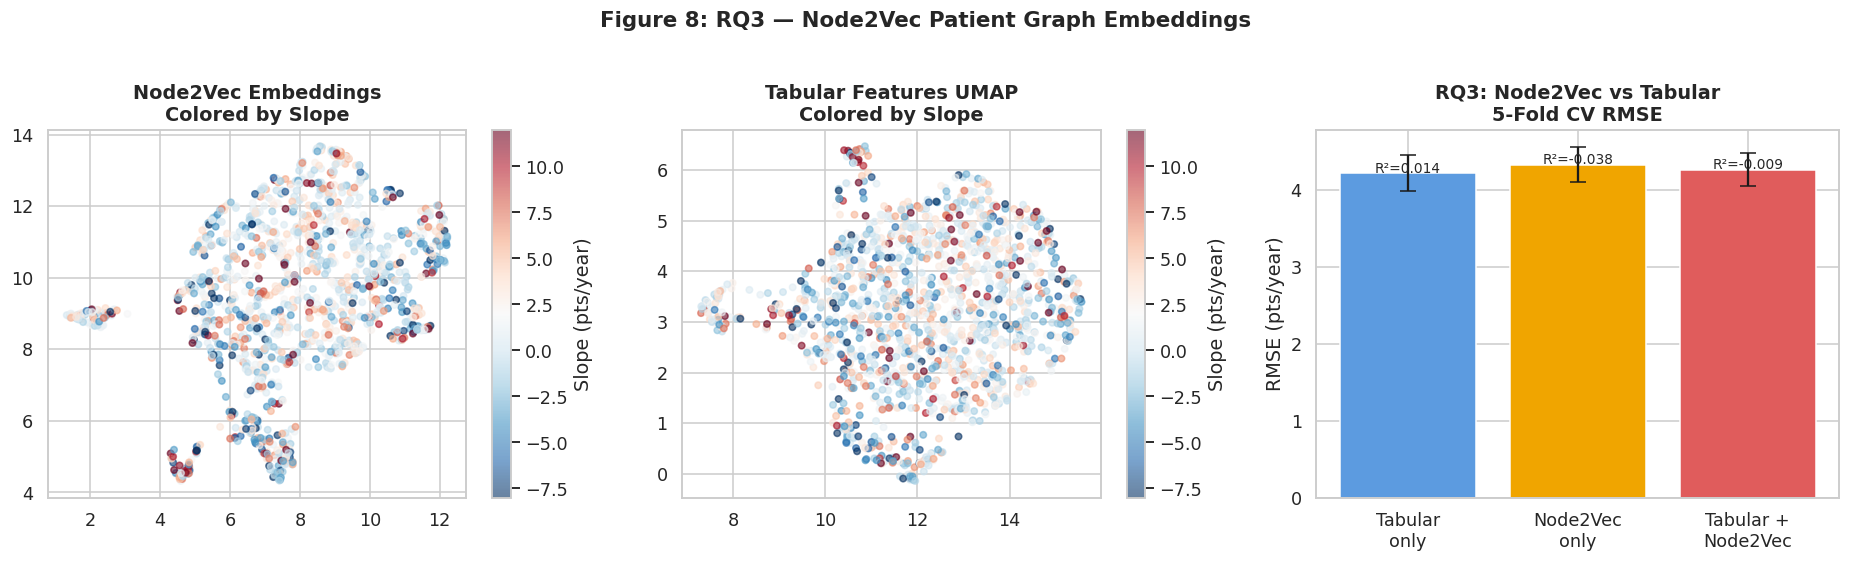

In [19]:
# ── Visualise graph + embedding space ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Node2Vec UMAP colored by slope
reducer2 = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
emb_2d   = reducer2.fit_transform(embeddings)
sc1 = axes[0].scatter(emb_2d[:,0], emb_2d[:,1], c=np.clip(y,-8,12),
                       cmap='RdBu_r', alpha=0.6, s=18, vmin=-8, vmax=12)
plt.colorbar(sc1, ax=axes[0], label='Slope (pts/year)')
axes[0].set_title('Node2Vec Embeddings\nColored by Slope', fontweight='bold')

# Tabular UMAP colored by slope
tab_2d = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X)
sc2 = axes[1].scatter(tab_2d[:,0], tab_2d[:,1], c=np.clip(y,-8,12),
                       cmap='RdBu_r', alpha=0.6, s=18, vmin=-8, vmax=12)
plt.colorbar(sc2, ax=axes[1], label='Slope (pts/year)')
axes[1].set_title('Tabular Features UMAP\nColored by Slope', fontweight='bold')

# RMSE bar chart
short_names = ['Tabular\nonly','Node2Vec\nonly','Tabular +\nNode2Vec']
rmses3 = [rq3[k]['RMSE'] for k in configs]
stds3  = [rq3[k]['RMSE_std'] for k in configs]
r2s3   = [rq3[k]['R2'] for k in configs]
axes[2].bar(short_names, rmses3, yerr=stds3,
            color=['#5C9BE0','#F0A500','#E05C5C'], capsize=5, edgecolor='white')
for i, (r, r2) in enumerate(zip(rmses3, r2s3)):
    axes[2].text(i, r+0.01, f'R²={r2:.3f}', ha='center', fontsize=9)
axes[2].set_title('RQ3: Node2Vec vs Tabular\n5-Fold CV RMSE', fontweight='bold')
axes[2].set_ylabel('RMSE (pts/year)')

plt.suptitle('Figure 8: RQ3 — Node2Vec Patient Graph Embeddings', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH + 'fig8_node2vec.png', bbox_inches='tight')
plt.show()


## 9. Full Results Summary Table

In [20]:
import pandas as pd

summary = {
    'Metric': [
        'Labeled patients (total)',
        'PD patients',
        'SWEDD patients',
        'HC patients',
        'Prodromal patients',
        'Clinical visit rows',
        'Clinical features',
        'Patients with reliable slopes',
        'PD mean slope (pts/year)',
        'PD slope std (pts/year)',
        'PD fast progressors (>5 pts/yr)',
        'PD slow/stable (<1 pt/yr)',
        'Max |Spearman ρ| (feat vs slope)',
        'Best regression RMSE (GBM)',
        'Best regression R² (GBM)',
        'Naive baseline RMSE',
        'Hopkins statistic H',
        'Optimal K (Silhouette)',
        'K-Means Silhouette (K=4)',
        'Graph clustering coeff (patient)',
        'Graph clustering coeff (random)',
        'Graph avg path (patient)',
        'Graph avg path (random)',
        'RMSE improvement — Node2Vec',
    ],
    'Value': [
        f"{len(labels):,}",
        f"{(labels['LABEL']=='PD').sum():,}",
        f"{(labels['LABEL']=='SWEDD').sum():,}",
        f"{(labels['LABEL']=='HC').sum():,}",
        f"{(labels['LABEL']=='Prodromal').sum():,}",
        f"{len(merged):,}",
        f"{len(SCORE_COLS)}",
        f"{len(reliable):,}",
        f"{pd_s.mean():.3f}",
        f"{pd_s.std():.3f}",
        f"{(pd_s>5).sum()} ({(pd_s>5).mean()*100:.1f}%)",
        f"{(pd_s<1).sum()} ({(pd_s<1).mean()*100:.1f}%)",
        f"{cr_df['rho'].abs().max():.3f}",
        f"{results['Gradient Boosting']['RMSE']:.3f} ± {results['Gradient Boosting']['RMSE_std']:.3f}",
        f"{results['Gradient Boosting']['R2']:.3f}",
        f"{y.std():.3f}",
        f"{H:.4f}",
        f"{best_k}",
        f"{sil_km:.4f}",
        f"{avg_cc:.4f}",
        f"{rand_cc:.4f}",
        f"{avg_path:.3f}",
        f"{rand_path:.3f}",
        f"{delta:+.4f} pts/year",
    ]
}
summary_df = pd.DataFrame(summary)
print("="*60)
print("  COMPLETE RESULTS SUMMARY — MILESTONE 2")
print("="*60)
print(summary_df.to_string(index=False))
summary_df.to_csv(FIG_PATH + 'results_summary.csv', index=False)
print(f"\n✓ Saved results_summary.csv")
print(f"\nAll figures saved to: {FIG_PATH}")
import os
for f in sorted(os.listdir(FIG_PATH)):
    if f.endswith('.png') or f.endswith('.csv'):
        sz = os.path.getsize(FIG_PATH+f)/1e3
        print(f"  {f}  ({sz:.0f} KB)")


  COMPLETE RESULTS SUMMARY — MILESTONE 2
                          Metric            Value
        Labeled patients (total)            4,899
                     PD patients            1,790
                  SWEDD patients            1,659
                     HC patients            1,149
              Prodromal patients              101
             Clinical visit rows           42,157
               Clinical features               19
   Patients with reliable slopes            2,961
        PD mean slope (pts/year)            1.133
         PD slope std (pts/year)            4.262
 PD fast progressors (>5 pts/yr)      190 (13.0%)
       PD slow/stable (<1 pt/yr)      726 (49.5%)
Max |Spearman ρ| (feat vs slope)            0.086
      Best regression RMSE (GBM)    4.169 ± 0.190
        Best regression R² (GBM)            0.036
             Naive baseline RMSE            4.261
             Hopkins statistic H           0.8254
          Optimal K (Silhouette)                2
        K